### 1.) Import Libraries

In [2]:
# OS
import os

# DataFrame
import pandas as pd
import numpy as np

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Datetime
import datetime

# Data Preparation
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Modelling
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score
import tensorflow as tf

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Mengatur Tema Plotting
sns.set_theme(style="white")
sns.set_palette(["red", "blue", "black"])

#

### 2. Business Understanding

#### 2.2 Introduction

Business understanding pada kasus credit risk berfokus pada bagaimana **perusahaan atau lembaga keuangan menilai kemungkinan seorang nasabah gagal membayar pinjaman** sehingga dapat meminimalkan kerugian dan menjaga kualitas portofolio kredit. Proses ini mencakup pemahaman terhadap tujuan bisnis seperti meningkatkan akurasi persetujuan kredit, mengurangi tingkat kredit macet, serta menjaga keseimbangan antara risiko dan keuntungan. Dalam praktiknya, data seperti riwayat pembayaran, pendapatan, pekerjaan, jumlah pinjaman, dan perilaku transaksi digunakan untuk mengidentifikasi karakteristik nasabah yang berisiko tinggi maupun rendah, sehingga perusahaan dapat mengambil keputusan kredit yang lebih tepat dan efisien.

Diketahui bahwa tahapan peminjaman kredit diantaranya sebagai berikut,


| Tahapan | Deskripsi |
|---|---|
| Permohonan Pinjaman | Klien mengajukan permohonan pinjaman dengan mengisi dokumen aplikasi pinjaman. |
| Pengecekan Klien | Sistem memeriksa apakah klien sudah terdaftar di sistem. |
| Dokumen Legal | Klien menyerahkan dokumen legal yang diperlukan. |
| Penilaian Aplikasi | Sistem melakukan penilaian terhadap aplikasi pinjaman berdasarkan dokumen yang diserahkan dan profil klien. |
| Negosiasi | Jika diperlukan, dilakukan negosiasi antara klien dan pihak peminjam terkait persyaratan pinjaman. |
| Persetujuan | Jika aplikasi disetujui, klien akan menerima persetujuan pinjaman dan perjanjian pinjaman. |
| Penandatanganan | Klien menandatangani perjanjian pinjaman. |
| Penyesuaian | Jika diperlukan, dilakukan penyesuaian terhadap jumlah pinjaman dan jadwal pembayaran. |
| Pencairan | Pinjaman dicairkan kepada klien. |
| Pembayaran | Klien melakukan pembayaran pinjaman sesuai dengan jadwal yang telah disepakati. |
| Pelunasan | Pinjaman dianggap lunas setelah seluruh pembayaran diterima. |
| Penolakan | Jika aplikasi ditolak, klien akan menerima pemberitahuan penolakan. |

#### 2.2 Problem Statement

Berdasarkan pemahaman bisnis yang telah diuraikan, proyek ini akan berfokus pada beberapa permasalahan berikut:

1. Bagaimana melakukan proses data cleaning dan preprocessing yang tepat untuk mendukung pemodelan credit risk?
2. Variabel apa saja yang berpengaruh terhadap risiko kredit, serta bagaimana cara menangani data yang hilang (missing values) pada dataset?
3. Bagaimana menangani ketidakseimbangan kelas (class imbalance) dalam dataset agar model dapat memberikan performa prediksi yang optimal?
4. Bagaimana membandingkan kelebihan dan kekurangan dari berbagai algoritma machine learning yang digunakan dalam pemodelan credit risk?
5. Model machine learning apa yang paling efektif dalam memprediksi risiko kredit berdasarkan hasil evaluasi performa model?

#

### 3. Data Understanding

> Dataset pada proyek ini menggunakan data pinjaman yang disediakan oleh Rakamin Academy dalam program Project Based Internship. Dataset tersebut berisi 466.285 data dengan 75 variabel dan dapat diakses melalui tautan sumber dataset yang telah disediakan ([*Link Dataset*](https://rakamin-lms.s3.ap-southeast-1.amazonaws.com/vix-assets/idx-partners/loan_data_2007_2014.csv)).

In [12]:
data = pd.read_csv('loan_data_2007_2014.csv')
data.head()

C:\Users\Leonardo\AppData\Local\Temp\ipykernel_15192\1984146833.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('loan_data_2007_2014.csv')


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> Menampilan urutan kolom pada dataset

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

> Menghitung jumlah nilai NaN dalam setiap kolom.

In [16]:
data.isna().sum()

Unnamed: 0               0
id                       0
member_id                0
loan_amnt                0
funded_amnt              0
                     ...  
all_util            466285
total_rev_hi_lim     70276
inq_fi              466285
total_cu_tl         466285
inq_last_12m        466285
Length: 75, dtype: int64

Berdasarkan hasil pengecekan struktur data pada DataFrame, ditemukan beberapa kolom yang seluruh nilainya berupa NaN (_Not a Number_) sehingga tidak mengandung informasi yang dapat digunakan dalam analisis. Selain itu, terdapat pula kolom indeks yang tidak memiliki relevansi terhadap proses analisis maupun pemodelan. Oleh karena itu, dilakukan tahap pembersihan data dengan **menghapus kolom indeks serta kolom yang hanya berisi nilai kosong** atau NaN. Langkah ini bertujuan untuk meningkatkan kualitas data agar lebih bersih, relevan, dan siap digunakan dalam proses analisis maupun pembangunan model.

> Menghapus kolom indeks dan kolom yang hanya berisi nilai NaN.

In [19]:
data = data.drop(columns = ['Unnamed: 0'])
data = data.dropna(axis=1, how='all')

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           466285 non-null  int64  
 1   member_id                    466285 non-null  int64  
 2   loan_amnt                    466285 non-null  int64  
 3   funded_amnt                  466285 non-null  int64  
 4   funded_amnt_inv              466285 non-null  float64
 5   term                         466285 non-null  object 
 6   int_rate                     466285 non-null  float64
 7   installment                  466285 non-null  float64
 8   grade                        466285 non-null  object 
 9   sub_grade                    466285 non-null  object 
 10  emp_title                    438697 non-null  object 
 11  emp_length                   445277 non-null  object 
 12  home_ownership               466285 non-null  object 
 13 

#### 2.1 Data Dictionary

Pada tahap ini dilakukan penyusunan kamus data untuk memahami makna dan konteks dari setiap variabel pada dataset pinjaman. Selain itu, dilakukan pula proses identifikasi terhadap fitur-fitur yang dianggap tidak relevan untuk kebutuhan pemodelan. Tahapan ini bertujuan untuk meningkatkan efektivitas analisis serta memastikan proses pengolahan data dilakukan secara lebih terstruktur dan profesional.

Berikut merupakan kamus data yang digunakan untuk membantu memahami karakteristik setiap variabel dalam loan dataset.

> Catatan Penting

- Variabel yang ditandai dengan huruf **tebal** diasumsikan diperoleh setelah proses pelunasan pinjaman berlangsung. Oleh karena itu, analisis difokuskan pada variabel yang memiliki keterkaitan langsung dengan informasi status pinjaman.
- Beberapa variabel seperti `id`, `member_id`, dan `url` dianggap tidak relevan dalam proses analisis karena hanya berfungsi sebagai identitas unik atau metadata yang tidak memberikan informasi terkait karakteristik maupun performa pinjaman.

| Variabel | Deskripsi |
|---|---|
| **id** | ID unik yang ditetapkan LC untuk listing pinjaman. |
| **member_id** | ID unik yang ditetapkan LC untuk anggota peminjam. |
| loan_amnt | Jumlah pinjaman yang diajukan oleh peminjam. Jika departemen kredit mengurangi jumlah pinjaman, nilainya akan tercermin di sini. |
| funded_amnt | Jumlah total yang dikomitkan untuk pinjaman tersebut pada saat itu. |
| funded_amnt_inv | Jumlah total yang dikomitkan oleh investor untuk pinjaman tersebut pada saat itu. |
| term | Jumlah pembayaran pinjaman. Nilai dalam bulan dan bisa 36 atau 60. |
| int_rate | Suku Bunga pinjaman |
| installment | Pembayaran bulanan yang terutang oleh peminjam jika pinjaman berasal. |
| grade | Tingkat pinjaman yang ditetapkan LC |
| sub_grade | Subtingkat pinjaman yang ditetapkan LC |
| emp_title | Jabatan yang diberikan oleh Peminjam saat mengajukan pinjaman. |
| emp_length | Lamanya bekerja dalam tahun. Nilai kemungkinan antara 0 dan 10 dimana 0 berarti kurang dari satu tahun dan 10 berarti sepuluh tahun atau lebih. |
| home_ownership | Status kepemilikan rumah yang diberikan oleh peminjam saat pendaftaran. Nilai yang mungkin: SEWA, MILIK, KPR, LAINNYA. |
| annual_inc | Penghasilan tahunan yang dilaporkan sendiri oleh peminjam saat pendaftaran. |
| verification_status | Menunjukkan apakah pendapatan diverifikasi oleh LC, tidak diverifikasi, atau jika sumber pendapatan diverifikasi. |
| **issue_d** | Bulan dimana pinjaman didanai |
| loan_status | Status pinjaman saat ini |
| pymnt_plan | Menunjukkan apakah rencana pembayaran telah ditetapkan untuk pinjaman |
| **url** | URL untuk halaman LC dengan data listing. |
| desc | Deskripsi pinjaman yang diberikan oleh peminjam |
| purpose | Kategori yang diberikan oleh peminjam untuk permintaan pinjaman. |
| title | Judul pinjaman yang diberikan oleh peminjam |
| zip_code | 3 digit awal dari kode pos yang diberikan oleh peminjam dalam aplikasi pinjaman. |
| addr_state | Negara bagian yang diberikan oleh peminjam dalam aplikasi pinjaman |
| dti | Rasio yang dihitung menggunakan total pembayaran hutang bulanan peminjam pada total kewajiban hutang, tidak termasuk hipotek dan pinjaman LC yang diminta, dibagi dengan pendapatan bulanan yang dilaporkan sendiri oleh peminjam. |
| **delinq_2yrs** | Jumlah kejadian terlambat pembayaran 30+ hari dalam catatan kredit peminjam selama 2 tahun terakhir. |
| earliest_cr_line | Bulan dimana jalur kredit terawal peminjam dibuka |
| **inq_last_6mths** | Jumlah penyelidikan dalam 6 bulan terakhir (tidak termasuk penyelidikan auto dan hipotek) |
| **mths_since_last_delinq** | Jumlah bulan sejak keterlambatan pembayaran terakhir peminjam. |
| **mths_since_last_record** | Jumlah bulan sejak catatan publik terakhir. |
| open_acc | Jumlah jalur kredit terbuka dalam catatan kredit peminjam. |
| pub_rec | Jumlah catatan publik yang merugikan |
| revol_bal | Total saldo kredit bergulir |
| revol_util | Rasio penggunaan kredit bergulir, atau jumlah kredit yang digunakan peminjam relatif terhadap semua kredit bergulir yang tersedia. |
| total_acc | Jumlah total jalur kredit yang saat ini ada di file kredit peminjam |
| initial_list_status | Status pencatatan awal untuk pinjaman. Kemungkinan nilainya adalah - Keseluruhan, Sebagian |
| **out_prncp** | Sisa pokok terutang untuk total keseluruhan yang didanai |
| **out_prncp_inv** | Sisa pokok terutang untuk porsi dari total keseluruhan yang didanai oleh investor |
| **total_pymnt** | Pembayaran yang diterima hingga saat ini untuk total keseluruhan yang didanai |
| **total_pymnt_inv** | Pembayaran yang diterima hingga saat ini untuk porsi dari total keseluruhan yang didanai oleh investor |
| **total_rec_prncp** | Pokok yang diterima hingga saat ini |
| **total_rec_int** | Bunga yang diterima hingga saat ini |
| **total_rec_late_fee** | Biaya keterlambatan yang diterima hingga saat ini |
| **recoveries** | Pemulihan bruto setelah penghapusan buku |
| **collection_recovery_fee** | Biaya pemulihan setelah penghapusan buku |
| **last_pymnt_d** | Bulan terakhir pembayaran diterima |
| **last_pymnt_amnt** | Jumlah total pembayaran terakhir yang diterima |
| **next_pymnt_d** | Tanggal pembayaran terjadwal berikutnya |
| **last_credit_pull_d** | Bulan terakhir LC menarik kredit untuk pinjaman ini |
| **collections_12_mths_ex_med** | Jumlah penagihan dalam 12 bulan tidak termasuk penagihan medis |
| **mths_since_last_major_derog** | Bulan sejak peringkat terburuk 90 hari atau lebih terakhir |
| policy_code | Kode kebijakan yang tersedia untuk umum: policy_code=1 produk baru yang tidak tersedia untuk umum policy_code=2 |
| application_type | Menunjukkan apakah pinjaman tersebut merupakan pengajuan individu atau pengajuan bersama dengan dua peminjam bersama |
| acc_now_delinq | Jumlah akun di mana peminjam saat ini terlambat. |
| **tot_coll_amt** | Total jumlah penagihan yang pernah terutang |
| **tot_cur_bal** | Total saldo saat ini dari semua akun |
| **total_rev_hi_lim** | Total batas kredit/kredit limit tertinggi untuk kredit bergulir |

> Menghapus kolom yang tidak relevan.

In [26]:
irrelevant_features = [
    'id', 'member_id', 'issue_d', 'url', 'delinq_2yrs', 'inq_last_6mths',
    'mths_since_last_delinq', 'mths_since_last_record', 'out_prncp',
    'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'tot_coll_amt',
    'tot_cur_bal', 'total_rev_hi_lim'
]

data = data.drop(irrelevant_features, axis=1)

#

### 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (**EDA**) merupakan tahap eksplorasi awal data untuk memahami karakteristik utama dalam dataset. Proses ini bertujuan mengidentifikasi pola, hubungan, serta anomali melalui statistik deskriptif dan visualisasi data, sehingga dapat memberikan pemahaman yang lebih baik sebelum dilakukan analisis lanjutan atau pembangunan model prediktif.

#### 3.1 Deskripsi Variabel

Tahap ini merujuk pada proses analisis yang bertujuan untuk memahami **struktur, karakteristik, dan informasi** yang terkandung dalam variabel-variabel yang digunakan dalam suatu dataset.

> Menampilkan informasi terperinci tentang struktur data pada DataFrame.

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amnt            466285 non-null  int64  
 1   funded_amnt          466285 non-null  int64  
 2   funded_amnt_inv      466285 non-null  float64
 3   term                 466285 non-null  object 
 4   int_rate             466285 non-null  float64
 5   installment          466285 non-null  float64
 6   grade                466285 non-null  object 
 7   sub_grade            466285 non-null  object 
 8   emp_title            438697 non-null  object 
 9   emp_length           445277 non-null  object 
 10  home_ownership       466285 non-null  object 
 11  annual_inc           466281 non-null  float64
 12  verification_status  466285 non-null  object 
 13  loan_status          466285 non-null  object 
 14  pymnt_plan           466285 non-null  object 
 15  desc             

> Menghasilkan ringkasan statistik deskriptif dari dataset.

In [35]:
data.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,policy_code,acc_now_delinq
count,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,466256.000000,466256.000000,4.662850e+05,465945.000000,466256.000000,466285.0,466256.000000
mean,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,11.187069,0.160564,1.623020e+04,56.176947,25.064430,1.0,0.004002
std,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,4.987526,0.510863,2.067625e+04,23.732628,11.600141,0.0,0.068637
min,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,1.0,0.000000
25%,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,8.000000,0.000000,6.413000e+03,39.200000,17.000000,1.0,0.000000
50%,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,10.000000,0.000000,1.176400e+04,57.600000,23.000000,1.0,0.000000
75%,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,14.000000,0.000000,2.033300e+04,74.700000,32.000000,1.0,0.000000
max,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,84.000000,63.000000,2.568995e+06,892.300000,156.000000,1.0,5.000000


> Melihat informasi tentang kolom-kolom yang memiliki tipe data objek (string).

In [37]:
data.select_dtypes(include=object).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   term                 466285 non-null  object
 1   grade                466285 non-null  object
 2   sub_grade            466285 non-null  object
 3   emp_title            438697 non-null  object
 4   emp_length           445277 non-null  object
 5   home_ownership       466285 non-null  object
 6   verification_status  466285 non-null  object
 7   loan_status          466285 non-null  object
 8   pymnt_plan           466285 non-null  object
 9   desc                 125981 non-null  object
 10  purpose              466285 non-null  object
 11  title                466264 non-null  object
 12  zip_code             466285 non-null  object
 13  addr_state           466285 non-null  object
 14  earliest_cr_line     466256 non-null  object
 15  initial_list_status  466285 non-nu

> Menghitung jumlah nilai unik dalam setiap kolom yang memiliki tipe data objek (string).

In [39]:
data.select_dtypes(include=object).nunique()

term                        2
grade                       7
sub_grade                  35
emp_title              205475
emp_length                 11
home_ownership              6
verification_status         3
loan_status                 9
pymnt_plan                  2
desc                   124435
purpose                    14
title                   63098
zip_code                  888
addr_state                 50
earliest_cr_line          664
initial_list_status         2
application_type            1
dtype: int64

> Melihat informasi tentang kolom-kolom yang memiliki tipe data numerik.

In [41]:
data.select_dtypes(include='number').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   loan_amnt        466285 non-null  int64  
 1   funded_amnt      466285 non-null  int64  
 2   funded_amnt_inv  466285 non-null  float64
 3   int_rate         466285 non-null  float64
 4   installment      466285 non-null  float64
 5   annual_inc       466281 non-null  float64
 6   dti              466285 non-null  float64
 7   open_acc         466256 non-null  float64
 8   pub_rec          466256 non-null  float64
 9   revol_bal        466285 non-null  int64  
 10  revol_util       465945 non-null  float64
 11  total_acc        466256 non-null  float64
 12  policy_code      466285 non-null  int64  
 13  acc_now_delinq   466256 non-null  float64
dtypes: float64(10), int64(4)
memory usage: 49.8 MB


> Menghitung jumlah nilai unik dalam setiap kolom yang memiliki tipe data numerik.

In [43]:
data.select_dtypes(include='number').nunique()

loan_amnt           1352
funded_amnt         1354
funded_amnt_inv     9854
int_rate             506
installment        55622
annual_inc         31901
dti                 3997
open_acc              62
pub_rec               26
revol_bal          58142
revol_util          1269
total_acc            112
policy_code            1
acc_now_delinq         6
dtype: int64

> **Important Inferences**

1. Berdasarkan hasil analisis variabel, diperoleh informasi mengenai jumlah baris dan kolom, tipe data, keberadaan missing value, variasi data kategorikal maupun numerik, serta statistik deskriptif pada variabel numerik dalam dataset.

2. Setelah dilakukan penghapusan kolom indeks, kolom yang hanya berisi nilai kosong (NaN), serta fitur yang tidak relevan, dataset akhir terdiri dari 31 kolom, yaitu 17 kolom bertipe object, 4 kolom numerik bertipe integer, dan 10 kolom numerik bertipe float.

#

#### 3.2 Feature Engineering

Pada tahap ini dilakukan _feature engineering_ dengan membuat fitur-fitur baru dari data yang telah tersedia guna meningkatkan performa model _machine learning_.

> Mendapatkan nilai unik dari setiap kolom dalam DataFrame.

In [49]:
unique_values = data.apply(lambda x: x.unique())
unique_values

loan_amnt              [5000, 2500, 2400, 10000, 3000, 7000, 5600, 53...
funded_amnt            [5000, 2500, 2400, 10000, 3000, 7000, 5600, 53...
funded_amnt_inv        [4975.0, 2500.0, 2400.0, 10000.0, 3000.0, 5000...
term                                            [ 36 months,  60 months]
int_rate               [10.65, 15.27, 15.96, 13.49, 12.69, 7.9, 18.64...
installment            [162.87, 59.83, 84.33, 339.31, 67.79, 156.46, ...
grade                                              [B, C, A, E, F, D, G]
sub_grade              [B2, C4, C5, C1, B5, A4, E1, F2, C3, B1, D1, A...
emp_title              [nan, Ryder, AIR RESOURCES BOARD, University M...
emp_length             [10+ years, < 1 year, 1 year, 3 years, 8 years...
home_ownership                   [RENT, OWN, MORTGAGE, OTHER, NONE, ANY]
annual_inc             [24000.0, 30000.0, 12252.0, 49200.0, 80000.0, ...
verification_status            [Verified, Source Verified, Not Verified]
loan_status            [Fully Paid, Charged Off, Cu

Berdasarkan hasil analisis pada kolom-kolom yang memiliki nilai unik, dilakukan penerapan feature engineering pada kolom `loan_status`. Kolom tersebut dipilih sebagai variabel target karena memuat informasi terkait status pinjaman.

> Menghitung frekuensi kemunculan setiap nilai unik dalam kolom `loan_status`.

In [52]:
data['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

Berdasarkan informasi di atas, dapat disimpulkan bahwa kolom 'loan_status' dalam dataset memiliki beberapa status pinjaman yang termasuk:

1. `Current`: Terdapat 224,226 entri yang menunjukkan pinjaman yang saat ini masih aktif.
2. `Fully Paid`: Terdapat 184,739 entri yang menunjukkan pinjaman yang telah sepenuhnya dilunasi.
3. `Charged Off`: Terdapat 42,475 entri yang menunjukkan pinjaman yang telah dinyatakan sebagai kerugian.
4. `Late (31-120 days)`: Terdapat 6,900 entri yang menunjukkan pinjaman yang telat pembayarannya antara 31 hingga 120 hari.
5. `In Grace Period`: Terdapat 3,146 entri yang menunjukkan pinjaman yang sedang dalam masa penundaan pembayaran.
6. `Does not meet the credit policy. Status:Fully Paid`: Terdapat 1,988 entri yang menunjukkan pinjaman yang selesai namun tidak memenuhi kebijakan kredit.
7. `Late (16-30 days)`: Terdapat 1,218 entri yang menunjukkan pinjaman yang telat pembayarannya antara 16 hingga 30 hari.
8. `Default`: Terdapat 832 entri yang menunjukkan pinjaman yang gagal membayar.
9. `Does not meet the credit policy. Status:Charged Off`: Terdapat 761 entri yang menunjukkan pinjaman yang dinyatakan sebagai kerugian dan tidak memenuhi kebijakan kredit.

Pada tahap ini, beberapa kelas pada variabel `loan_status` digabungkan ke dalam kategori yang lebih umum agar proses klasifikasi menjadi lebih sederhana. Kelas `Fully Paid` dan `Does not meet the credit policy`. Status: `Fully Paid` digabungkan menjadi kategori **positif**, sedangkan kelas `Charged Off` dan `Default` digabungkan menjadi kategori **negatif**. Pengelompokan ini bertujuan untuk mengurangi kompleksitas model, meningkatkan performa klasifikasi, meminimalkan risiko overfitting, serta mempermudah interpretasi hasil analisis.

> **Important Notes**

Kedua pasangan kelas tersebut dapat digabungkan karena merepresentasikan kondisi akhir pinjaman yang serupa. Kelas `Fully Paid` dan `Does not meet the credit policy`. Status: `Fully Paid` menunjukkan bahwa pinjaman telah berhasil dilunasi, sedangkan kelas `Charged Off` dan `Default` menunjukkan kegagalan dalam pelunasan pinjaman.

> `fully_paid_classes`: Terdiri dari kategori `Fully Paid` dan `Does not meet the credit policy. Status:Fully Paid`.

In [57]:
fully_paid_classes = ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']
df_fully_paid = data[data['loan_status'].isin(fully_paid_classes)]

> Menghitung jumlah total entri dalam kolom `loan_status` dari DataFrame `df_fully_paid`


In [59]:
df_fully_paid['loan_status'].value_counts().sum()

186727

Terdapat 186.727 data pinjaman yang berstatus telah dilunasi sepenuhnya.

> Membuat bar plot yang menunjukkan jumlah pinjaman untuk setiap status pinjaman `loan_status` di mana pinjaman lunas.

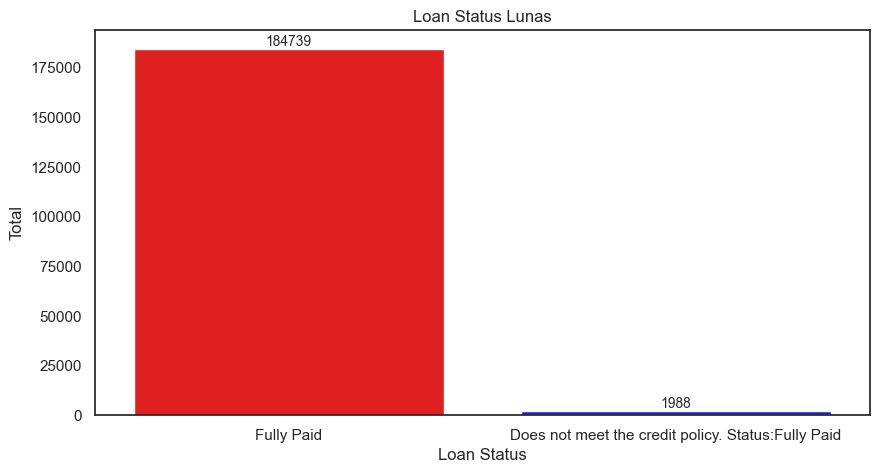

In [62]:
plt.figure(figsize=(10, 5))

count = df_fully_paid['loan_status'].value_counts()
ax = sns.barplot(x=count.index, y=count.values, hue=count.index, legend=False)

for i, container in enumerate(ax.containers):
    ax.bar_label(container, fontsize=10)

ax.set_title('Loan Status Lunas')
plt.xlabel('Loan Status')
plt.ylabel('Total')

plt.show()

> `charged_off_classes`: Terdiri dari kategori `Late (31-120 days)` dan `Late (16-30 days)`. Terdapat total 8,118 entri yang mencakup keterlambatan pembayaran, yang dapat digabungkan menjadi satu kategori.

In [64]:
charged_off_classes = ['Charged Off', 'Default']
df_charged_off = data[data['loan_status'].isin(charged_off_classes)]

> Menghitung jumlah total entri dalam kolom `loan_status` dari DataFrame `df_charged_off`

In [66]:
df_charged_off['loan_status'].value_counts().sum()

43307

Terdapat 43.307 entri yang menunjukkan pinjaman yang tidak dilunasi.

> Membuat bar plot yang menunjukkan jumlah pinjaman untuk setiap status pinjaman `loan_status` di mana tidak dilunasi.

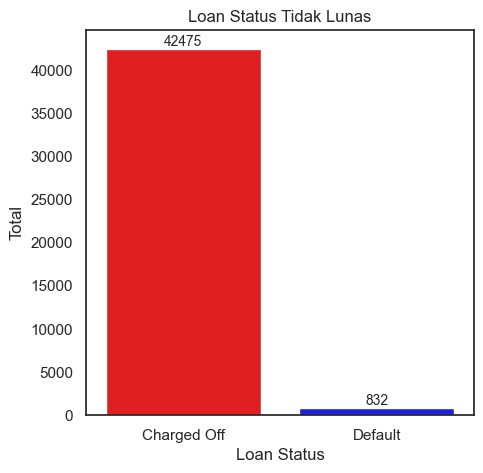

In [69]:
plt.figure(figsize=(5, 5))

count = df_charged_off['loan_status'].value_counts()
ax = sns.barplot(x=count.index, y=count.values, hue=count.index, legend=False)

for i, container in enumerate(ax.containers):
    ax.bar_label(container, fontsize=10)

ax.set_title('Loan Status Tidak Lunas')
plt.xlabel('Loan Status')
plt.ylabel('Total')

plt.show()

Dengan menggabungkan kategori-kategori ini, kini dataset memiliki beberapa kelas yang mencerminkan status pinjaman secara lebih umum.

> Mengganti nilai untuk `Fully Paid` dan `Does not meet the credit policy. Status:Fully Paid` menjadi `Fully Paid`.


In [72]:
data['loan_status'] = np.where(data['loan_status'].isin(["Fully Paid","Does not meet the credit policy. Status:Fully Paid"]),"Fully Paid",data['loan_status'])

> Mengganti nilai untuk `Charged Off` dan `Default` menjadi `Charged Off`.

In [74]:
data['loan_status'] = np.where(data['loan_status'].isin(["Charged Off","Default"]),"Charged Off",data['loan_status'])

> Menyaring DataFrame sehingga hanya mempertahankan baris yang memiliki nilai `Fully Paid` dan `Charged Off` dalam kolom `loan_status`.


In [76]:
data = data[data['loan_status'].isin(["Fully Paid", "Charged Off"])]

> Membuat bar plot yang menunjukkan jumlah pinjaman untuk setiap status pinjaman `loan_status`.

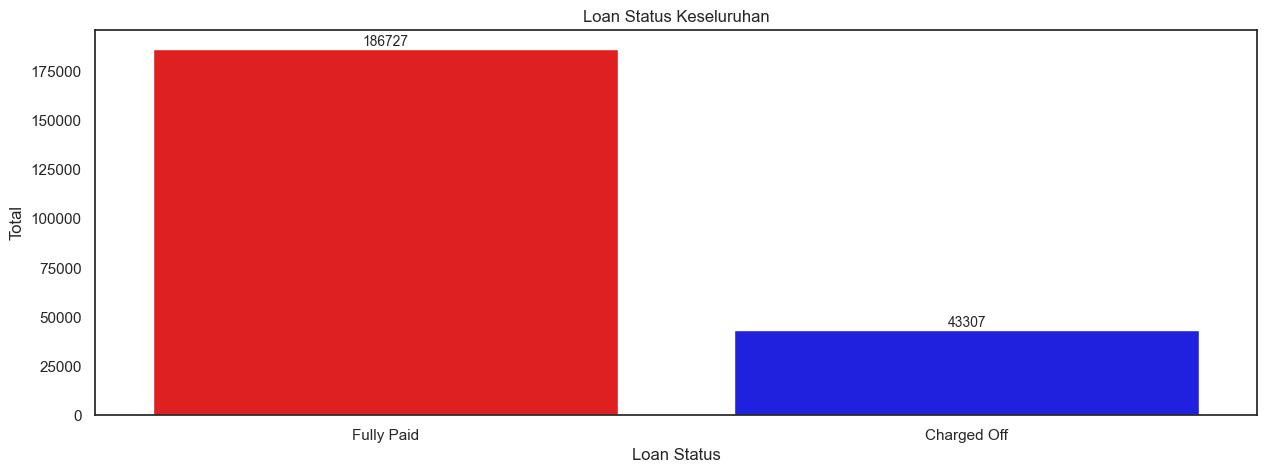

In [78]:
plt.figure(figsize=(15, 5))

count = data['loan_status'].value_counts()
ax = sns.barplot(x=count.index, y=count.values, hue=count.index, legend=False)

for i, container in enumerate(ax.containers):
    ax.bar_label(container, fontsize=10)

ax.set_title('Loan Status Keseluruhan')
plt.xlabel('Loan Status')
plt.ylabel('Total')

plt.show()

> Menghitung jumlah kemunculan setiap nilai dalam kolom `loan_status`.

In [80]:
data['loan_status'].value_counts()

loan_status
Fully Paid     186727
Charged Off     43307
Name: count, dtype: int64

#

#### 3.3 Data Analysis

##### 3.4.1 Univariate Analysis


Univariate Analysis merupakan metode analisis statistik yang digunakan untuk mempelajari karakteristik dari satu variabel dalam dataset. Analisis ini bertujuan untuk memahami distribusi data, pola, serta ukuran statistik utama seperti *mean*, median, modus, varians, dan standar deviasi sebelum dilakukan analisis lebih lanju 

Beberapa ukuran statistik yang umum digunakan dalam analisis univariat antara lain:

- Rata-rata (*mean*):

$$
\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}
$$

- Varians:

$$
s^2 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
$$

- Standar deviasi:

$$
s = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}}
$$

Ukuran-ukuran tersebut membantu memberikan gambaran mengenai penyebaran dan karakteristik data pada suatu variabel.

##### 3.4.1.1 Categorical Feature

In [86]:
# Melihat jumlah nilai unik pada setiap fitur
for col in data.columns:
    print(f"{col}: {data[col].nunique()} nilai unik")

loan_amnt: 1306 nilai unik
funded_amnt: 1309 nilai unik
funded_amnt_inv: 9180 nilai unik
term: 2 nilai unik
int_rate: 503 nilai unik
installment: 42890 nilai unik
grade: 7 nilai unik
sub_grade: 35 nilai unik
emp_title: 126396 nilai unik
emp_length: 11 nilai unik
home_ownership: 6 nilai unik
annual_inc: 18142 nilai unik
verification_status: 3 nilai unik
loan_status: 2 nilai unik
pymnt_plan: 2 nilai unik
desc: 89488 nilai unik
purpose: 14 nilai unik
title: 49005 nilai unik
zip_code: 873 nilai unik
addr_state: 50 nilai unik
dti: 3880 nilai unik
earliest_cr_line: 633 nilai unik
open_acc: 57 nilai unik
pub_rec: 12 nilai unik
revol_bal: 45856 nilai unik
revol_util: 1193 nilai unik
total_acc: 101 nilai unik
initial_list_status: 2 nilai unik
policy_code: 1 nilai unik
application_type: 1 nilai unik
acc_now_delinq: 6 nilai unik


> Menghapus kolom `application_type` dan `policy_code` karena hanya memiliki satu nilai unik.

In [88]:
data = data.drop(['application_type', 'policy_code'], axis=1)

> Menampilkan 10 baris pertama dari kolom `emp_title`.

In [90]:
data['emp_title'].head(10)

0                       NaN
1                     Ryder
2                       NaN
3       AIR RESOURCES BOARD
5      Veolia Transportaton
7           MKC Accounting 
8                       NaN
9                 Starbucks
10    Southwest Rural metro
11                     UCLA
Name: emp_title, dtype: object

> Menghitung jumlah nilai-nilai yang hilang (NaN) dalam kolom `emp_title`.

In [92]:
data['emp_title'].isna().sum()

12867

Berdasarkan hasil analisis pada tahap Deskripsi Variabel, diketahui bahwa variabel `emp_title` memiliki jumlah nilai unik yang sangat banyak serta mengandung **12.867** nilai NaN. Banyaknya kategori dan tingginya jumlah data yang hilang berpotensi menimbulkan kompleksitas serta mengurangi efektivitas proses pelatihan model. Oleh karena itu, kolom `emp_title` diputuskan untuk dihapus dari dataset.

> Menghapus kolom `emp_title` karena memiliki terlalu banyak nilai unik, yakni sebesar **12.867**.

In [95]:
data = data.drop(['emp_title'], axis=1)

> Melakukan pengecekkan pada kolom `earliest_cr_line`.


In [97]:
data['earliest_cr_line'].head(10)

0     Jan-85
1     Apr-99
2     Nov-01
3     Feb-96
5     Nov-04
7     Jan-07
8     Apr-04
9     Sep-04
10    Jan-98
11    Oct-89
Name: earliest_cr_line, dtype: object

> Mengubah kolom `earliest_cr_line` menjadi tipe data datetime. Kemudian menghasilkan deskripsi statistik dari kolom tersebut.

In [99]:
data['earliest_cr_line'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%y')

In [100]:
data['earliest_cr_line'].head(10)

0    1985-01-01
1    1999-04-01
2    2001-11-01
3    1996-02-01
5    2004-11-01
7    2007-01-01
8    2004-04-01
9    2004-09-01
10   1998-01-01
11   1989-10-01
Name: earliest_cr_line, dtype: datetime64[ns]

In [101]:
data['earliest_cr_line'].describe()

count                           230008
mean     1998-03-06 11:16:05.642934272
min                1969-01-01 00:00:00
25%                1994-09-01 00:00:00
50%                1999-05-01 00:00:00
75%                2002-09-01 00:00:00
max                2068-12-01 00:00:00
Name: earliest_cr_line, dtype: object

> Memperbaiki tanggal yang disimpan dalam format datetime.

In [103]:
def fix_date(x):                        # Membuat fungsi untuk memperbaiki nilai tanggal
    if pd.isnull(x):                    # Mengecek apakah nilai kosong / NaN
        return np.nan
    if x.year > 2030:                   # Mengecek apakah tahun lebih dari 2030; Hal ini biasanya terjadi karena kesalahan pembacaan tahun, Misalnya tahun 2068 seharusnya 1968
        year = x.year - 100             # Mengurangi 100 tahun untuk memperbaiki tahun yang salah
                                        
    else:                               
        year = x.year                   # Jika tahun normal, gunakan tahun asli
    return datetime.date(year, x.month, x.day)           # Mengembalikan tanggal baru dengan: tahun yang sudah diperbaiki, bulan dan hari tetap sama

# Menerapkan fungsi fix_date ke seluruh isi kolom earliest_cr_line
data['earliest_cr_line'] = data['earliest_cr_line'].apply(fix_date)

> Memberikan ringkasan statistik terkait kolom dengan tipe data datetime.

In [105]:
data['earliest_cr_line'].describe()

count         230008
unique           633
top       2000-10-01
freq            1967
Name: earliest_cr_line, dtype: object

> Format data dalam kolom `earliest_cr_line` dari datetime menjadi hanya tahun.

In [107]:
data['earliest_cr_line'] = pd.DatetimeIndex(data['earliest_cr_line']).year

> Menghitung jumlah nilai unik dalam kolom `earliest_cr_line`.

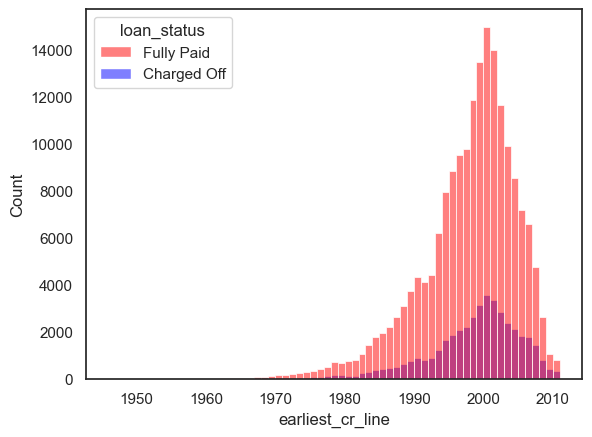

In [109]:
sns.histplot(data=data, x="earliest_cr_line", hue="loan_status", bins=65)

plt.show()

#

##### 3.3.1.2 Numerical Features

> Memberikan ringkasan statistik deskriptif pada kolom `loan_amnt`.

In [113]:
data['loan_amnt'].describe()

count    230034.000000
mean      13425.039342
std        8044.740493
min         500.000000
25%        7200.000000
50%       12000.000000
75%       18000.000000
max       35000.000000
Name: loan_amnt, dtype: float64

> Menghasilkan histogram untuk setiap kolom dalam DataFrame terhadap daata yang bersifat numerik.

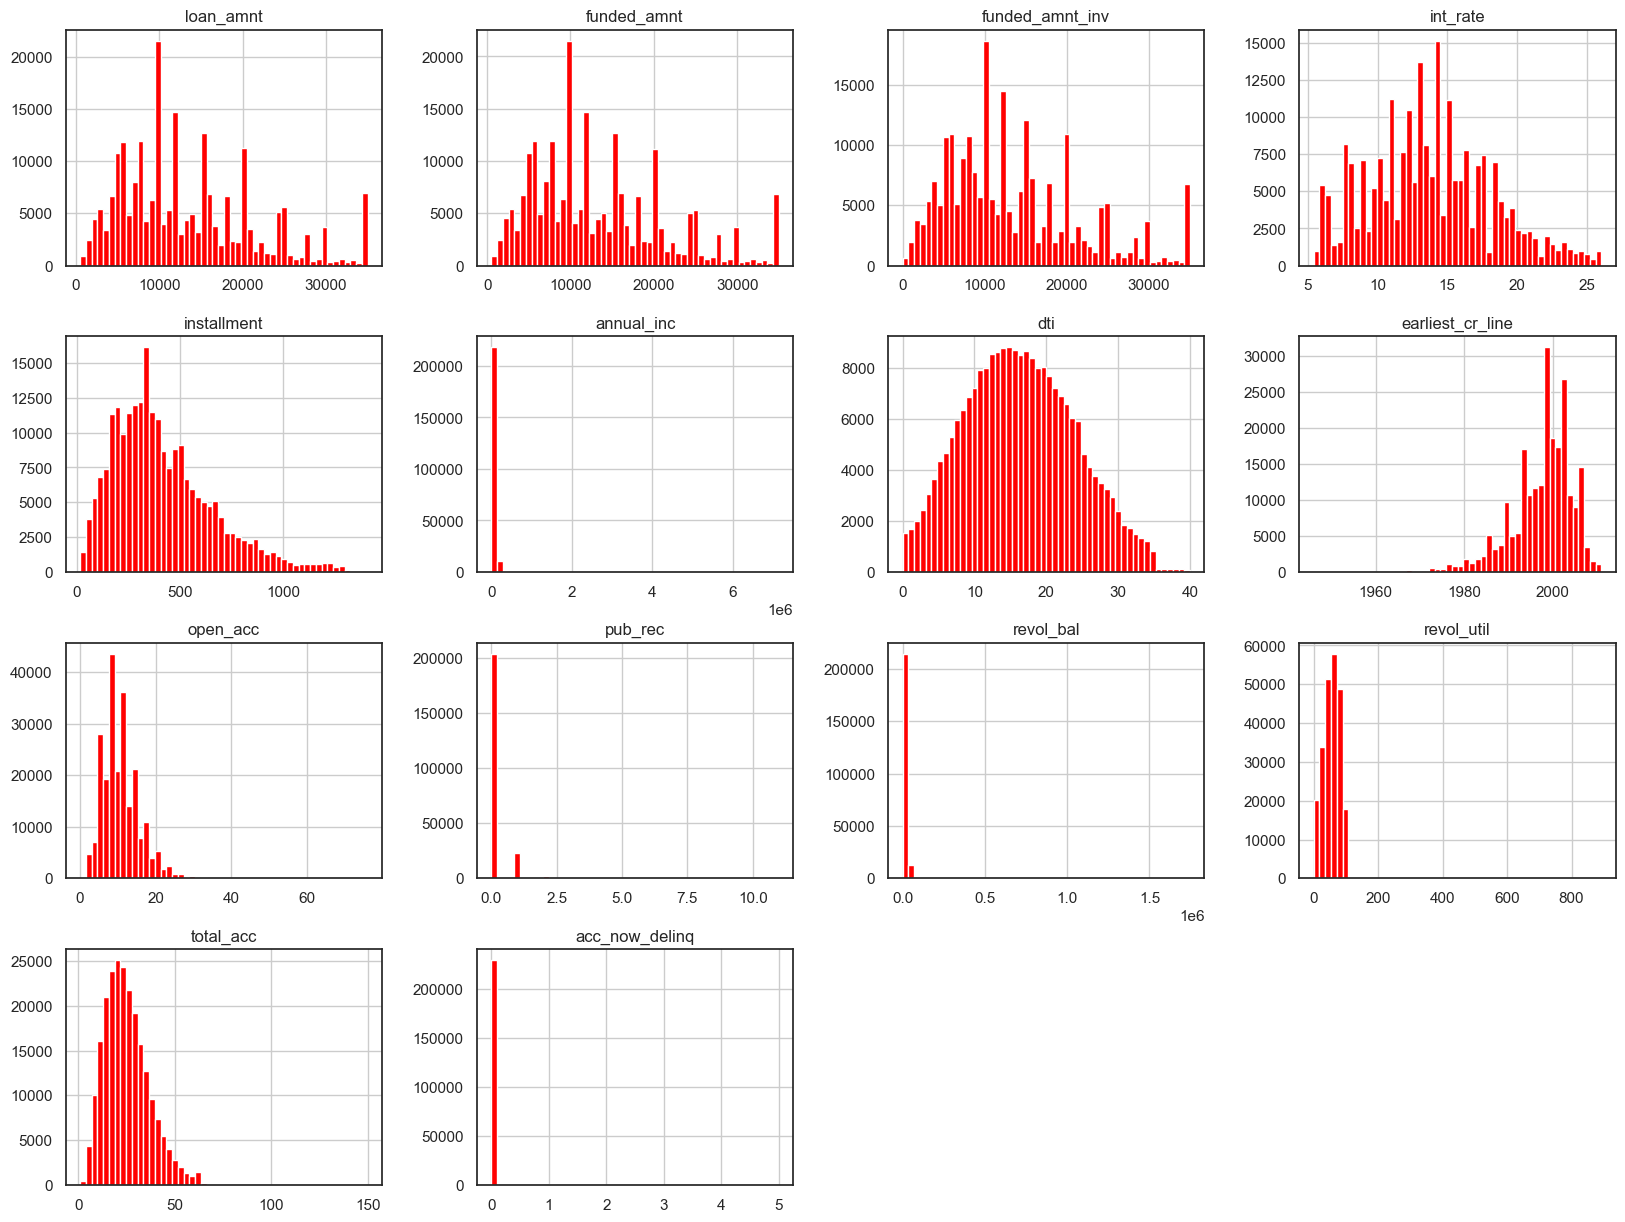

In [115]:
data.hist(bins=50, figsize=(20,15))
plt.show()

> **Important Inferences**

Pada tahap ini, analisis difokuskan pada variabel `loan_amnt` karena berdasarkan informasi pada Data Dictionary, variabel tersebut merepresentasikan jumlah pinjaman yang diajukan oleh peminjam. Berdasarkan hasil statistik deskriptif dan visualisasi histogram pada variabel numerik, diperoleh beberapa temuan berikut:

1. Rata-rata jumlah pinjaman berada pada kisaran **Rp14.317.277,57** dengan standar deviasi sebesar **Rp8.286.509,16**.
2. Mayoritas nilai pinjaman terkonsentrasi pada rentang **Rp8.000.000** hingga **Rp20.000.000**.
3. Nilai pinjaman minimum tercatat sebesar **Rp500.000**, sedangkan nilai maksimum mencapai **Rp35.000.000**.
4. Distribusi data pada variabel `loan_amnt` cenderung tidak simetris (skewed), yang menunjukkan adanya ketidakseimbangan penyebaran data pada jumlah pinjaman.

#

##### 3.2.2 Multivariate Analysis

Multivariate Analysis merupakan metode analisis statistik yang digunakan untuk mempelajari hubungan antara dua atau lebih variabel dalam suatu dataset. Analisis ini bertujuan untuk mengidentifikasi korelasi, pola, serta struktur hubungan yang kompleks antarvariabel sehingga dapat memberikan pemahaman yang lebih mendalam terhadap data dibandingkan analisis univariat.

##### 3.2.2.1 Categorical Features

> Melakukan pengecekkan pada kolom `desc`, `purpose`, and `title`.

In [122]:
data[['desc', 'purpose', 'title']].head(10)

,desc,purpose,title
0,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer
1,Borrower added on 12/22/11 > I plan to use t...,car,bike
2,NaN,small_business,real estate business
3,Borrower added on 12/21/11 > to pay for prop...,other,personel
5,NaN,wedding,My wedding loan I promise to pay back
7,Borrower added on 12/16/11 > Downpayment for...,car,Car Downpayment
8,Borrower added on 12/21/11 > I own a small h...,small_business,Expand Business & Buy Debt Portfolio
9,Borrower added on 12/16/11 > I'm trying to b...,other,Building my credit history.
10,Borrower added on 12/15/11 > I had recived a...,debt_consolidation,High intrest Consolidation
11,NaN,debt_consolidation,Consolidation


Apabila dilakukan peninjauan pada variabel `desc`, terdapat proporsi yang cukup besar dari deskripsi yang kosong. Oleh karena itu, peneliti mencoba mengekstrak variabel ini untuk memastkan apakah desc memiliki nilai NaN.

> Menambahkan kolom baru bernama `desc_is_na` ke dalam DataFrame.

In [125]:
data['desc_is_na'] = data['desc'].isna()

> Menghitung jumlah kemunculan (count) dari setiap nilai dalam kolom `desc_is_na`.

In [127]:
data['desc_is_na'].value_counts()

desc_is_na
True     139846
False     90188
Name: count, dtype: int64

> Membuat dua plot yang terdiri dari countplot yang menunjukkan jumlah kemunculan setiap kategori `desc_is_na` dengan membedakan warna berdasarkan `loan_status` dan stacked bar plot yang menunjukkan distribusi `loan_status` terhadap nilai `desc_is_na`.

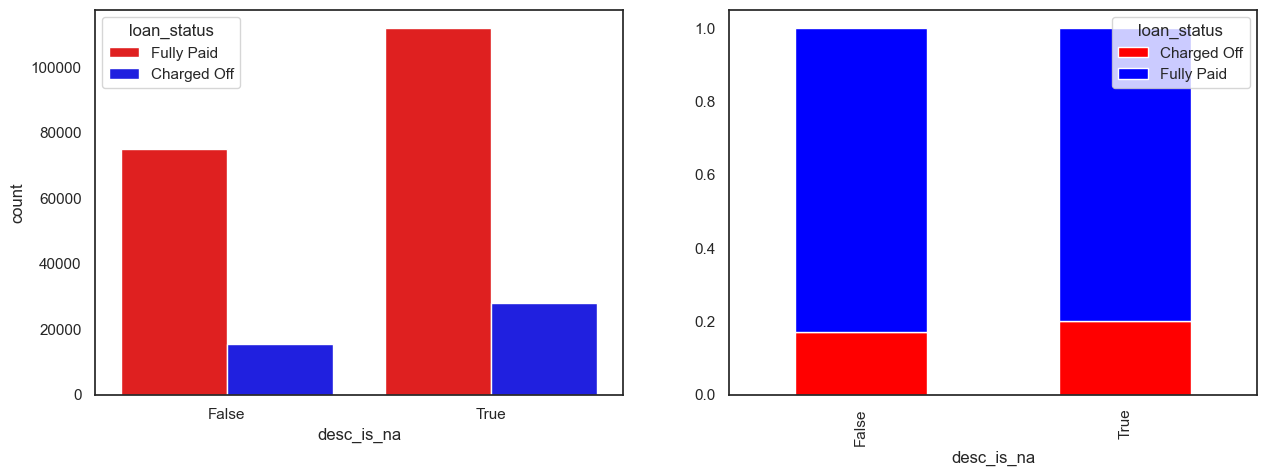

In [129]:
fig, axs = plt.subplots(ncols=2, figsize=(15, 5))
sns.countplot(data, x='desc_is_na', hue='loan_status', ax=axs[0])
data.groupby('desc_is_na')['loan_status'].value_counts(normalize=True).unstack('loan_status').plot.bar(stacked=True, ax=axs[1])

plt.show()

Berdasarkan visualisasi count plot, terlihat bahwa entri dengan deskripsi yang terisi (_False_) memiliki proporsi status pinjaman `Fully Paid` yang lebih tinggi. Selain itu, jumlah nilai True sebanyak **139.844** menunjukkan bahwa sebagian besar data tidak memiliki deskripsi pada kolom `desc`, sedangkan nilai _False_ sebanyak **90.190** menunjukkan adanya entri yang memiliki deskripsi.

Karena kolom `desc` mengandung banyak data yang tidak lengkap serta informasinya dianggap kurang relevan untuk proses pemodelan berdasarkan _Data Dictionary_, maka kolom tersebut diputuskan untuk dihapus dari dataset.

> Menghapus kolom `desc`.

In [132]:
data = data.drop('desc', axis=1)

> Menghitung jumlah nilai unik yang muncul dalam kolom `title` dan `purpose`. Kemudian mengambil sepuluh kombinasi nilai unik yang paling umum.

In [134]:
data[['title', 'purpose']].value_counts()[:10]

title                    purpose           
Debt consolidation       debt_consolidation    56195
Credit card refinancing  credit_card           18339
Debt Consolidation       debt_consolidation    10423
Home improvement         home_improvement       4980
Other                    other                  4602
Consolidation            debt_consolidation     3059
debt consolidation       debt_consolidation     3057
Debt Consolidation Loan  debt_consolidation     2976
Major purchase           major_purchase         1614
Business                 small_business         1467
Name: count, dtype: int64

Jika dilihat berdasarkan hasil dari perhitungan nilai di atas, dapat disimpulkan bahwa variabel purpose secara jelas diturunkan dari `title`. Oleh karena itu, `title` menjadi suatu variabel yang redundan dan telah dirangkum menjadi `purpose`.

> Menghapus kolom `title`.

In [137]:
data = data.drop('title', axis=1)

> Melakukan pengecekkan pada kolom `zip_code`  dan `addr_state`.

In [139]:
data[['zip_code', 'addr_state']].head(5)

,zip_code,addr_state
0,860xx,AZ
1,309xx,GA
2,606xx,IL
3,917xx,CA
5,852xx,AZ


> Menghitung jumlah kemunculan (count) kombinasi nilai dari dua kolom, yaitu `zip_code` dan `addr_state`.

In [141]:
data[['zip_code', 'addr_state']].value_counts()[:20]

zip_code  addr_state
945xx     CA            2968
112xx     NY            2646
750xx     TX            2522
100xx     NY            2370
900xx     CA            2290
606xx     IL            2282
331xx     FL            2082
300xx     GA            2070
070xx     NJ            2041
917xx     CA            1913
921xx     CA            1794
770xx     TX            1792
891xx     NV            1740
926xx     CA            1706
330xx     FL            1681
104xx     NY            1527
913xx     CA            1527
117xx     NY            1513
852xx     AZ            1493
925xx     CA            1442
Name: count, dtype: int64

> Mengambil 20 nilai teratas dari hasil perhitungan jumlah dari kolom `addr_state`.

In [143]:
data['addr_state'].value_counts()[:20].index.to_numpy()

array(['CA', 'NY', 'TX', 'FL', 'NJ', 'IL', 'PA', 'GA', 'VA', 'OH', 'NC',
       'MA', 'AZ', 'MD', 'MI', 'WA', 'CO', 'MN', 'MO', 'CT'], dtype=object)

> Membuat diagram batang yang menunjukkan jumlah pinjaman yang disetujui dan ditolak untuk 20 negara bagian teratas.

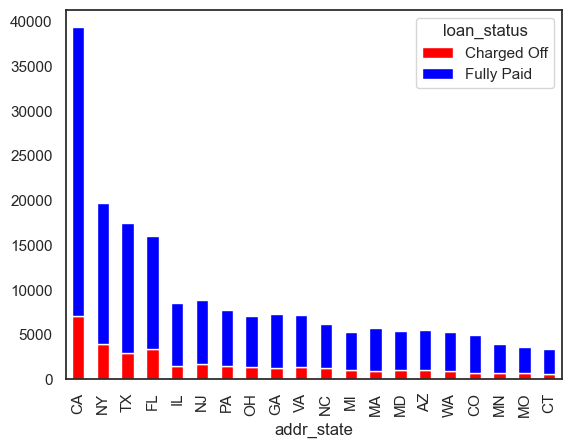

In [145]:
# Memilih 20 negara bagian dengan jumlah data terbanyak
top_20_state = ['CA', 'NY', 'TX', 'FL', 'IL', 'NJ', 'PA', 'OH', 'GA', 'VA',
                'NC', 'MI', 'MA', 'MD', 'AZ', 'WA', 'CO', 'MN', 'MO', 'CT']

# Memfilter dataset agar hanya berisi data dari 20 negara bagian tersebut
data_plot = data[data['addr_state'].isin(top_20_state)]

# Mengelompokkan data berdasarkan:
# 1. loan_status  -> status pinjaman (misalnya Fully Paid atau Charged Off)
# 2. addr_state   -> negara bagian peminjam
#
# .size() digunakan untuk menghitung jumlah data pada tiap kombinasi
data_plot = data_plot.groupby(['loan_status', 'addr_state']).size()

# Mengubah hasil groupby menjadi DataFrame, sehingga lebih mudah divisualisasikan
data_plot = data_plot.reset_index()

# Mengubah format tabel menjadi pivot table:
# - index   : addr_state
# - columns : loan_status
# - values  : jumlah data
#
# Hasil akhirnya: setiap baris = negara bagian; setiap kolom = status pinjaman
data_plot = data_plot.pivot(columns='loan_status', index='addr_state', values=0)


# Membuat stacked bar chart
# kind='bar'
# -> menampilkan diagram batang

# stacked=True
# -> setiap status pinjaman ditumpuk dalam satu batang, sehingga dapat membandingkan proporsi status pinjaman di masing-masing negara bagian

# Grafik ini membantu melihat:
# - negara bagian dengan jumlah pinjaman terbesar
# - perbandingan pinjaman lunas dan gagal bayar
# - distribusi loan_status pada tiap state
data_plot.loc[top_20_state].plot(kind='bar', stacked=True)

plt.show()

Tiga digit pertama pada `zip_code` merepresentasikan _sectional center_ sekaligus memberikan informasi mengenai negara bagian. Dengan demikian, terdapat informasi yang redundan antara variabel `zip_code` dan `addr_state`, karena informasi negara bagian pada `addr_state` sebenarnya sudah tercakup dalam tiga digit awal kode pos.

> **Important Notes**

Sectional center (pusat seksional) merupakan fasilitas pos utama di suatu wilayah yang bertanggung jawab atas pengelolaan dan distribusi pos di wilayah tersebut.

> Menghapus kolom `zip_code`.

In [149]:
data = data.drop('zip_code', axis=1)

> Menampilkan nilai unik yang terdapat dalam kolom `grade`.

In [151]:
print(data['grade'].unique())

['B' 'C' 'A' 'E' 'F' 'D' 'G']


> Menampilkan nilai unik yang terdapat dalam kolom `sub_grade`.

In [153]:
print(data['sub_grade'].unique())

['B2' 'C4' 'C5' 'C1' 'A4' 'E1' 'F2' 'B5' 'C3' 'B1' 'D1' 'A1' 'B3' 'B4'
 'C2' 'D2' 'A3' 'A5' 'D5' 'A2' 'E4' 'D3' 'D4' 'F3' 'E3' 'F1' 'E5' 'G4'
 'E2' 'G2' 'G1' 'F5' 'F4' 'G5' 'G3']


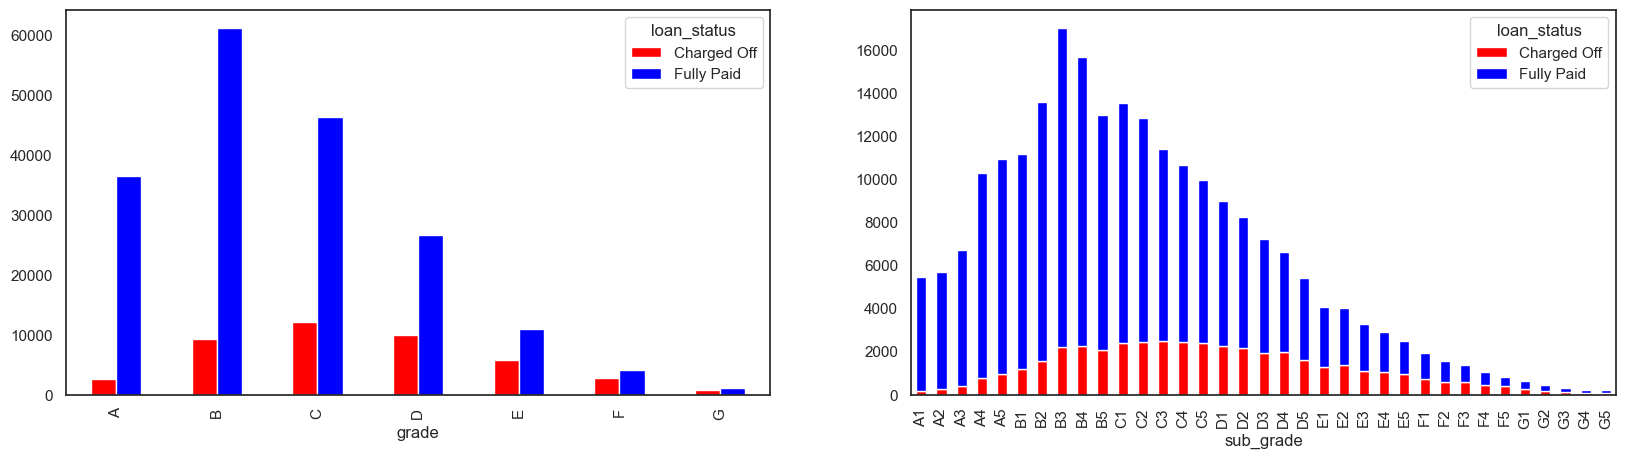

In [154]:
fig, axs = plt.subplots(ncols=2, figsize=(20, 5))
pd.crosstab(data['grade'], data['loan_status']).plot(kind='bar', ax=axs[0])
pd.crosstab(data['sub_grade'], data['loan_status']).plot(kind='bar', stacked=True, ax=axs[1])

plt.show()

> Membuat tabel silang antara kolom `grade` dan `loan_status` dan menormalisasi berdasarkan baris ('index').

In [156]:
pd.crosstab(data['grade'], data['loan_status'], normalize='index').round(2)

loan_status,Charged Off,Fully Paid
grade,,
A,0.07,0.93
B,0.13,0.87
C,0.21,0.79
D,0.27,0.73
E,0.35,0.65
F,0.40,0.60
G,0.42,0.58


> Membuat tabel silang antara kolom `sub_grade` dan `loan_status` dan menormalisasi berdasarkan baris ('index').

In [158]:
pd.crosstab(data['sub_grade'], data['loan_status'], normalize='index').round(2)

loan_status,Charged Off,Fully Paid
sub_grade,,
A1,0.03,0.97
A2,0.05,0.95
A3,0.06,0.94
A4,0.07,0.93
A5,0.09,0.91
B1,0.11,0.89
B2,0.11,0.89
B3,0.13,0.87
B4,0.15,0.85


Berdasarkan informasi di atas, dapat disimpulkan bahwa setiap `sub_grade` mencerminkan grade sehingga variabel grade dapat dihapus untuk mengurangi redudansi informasi.

> Menghapus kolom `grade`.

In [161]:
data = data.drop('grade', axis=1)

##### 3.3.2.2 Numerical Features

Pada analisis variabel numerik, salah satu tahapan yang umum dilakukan adalah analisis korelasi untuk mengukur hubungan antarvariabel. Analisis ini bertujuan untuk mengidentifikasi tingkat keterkaitan, mendeteksi redundansi data, serta mengetahui pengaruh hubungan antarvariabel terhadap independensi fitur dalam dataset.

> Membuat sebuah plot heatmap yang menampilkan matriks korelasi antar variabel.

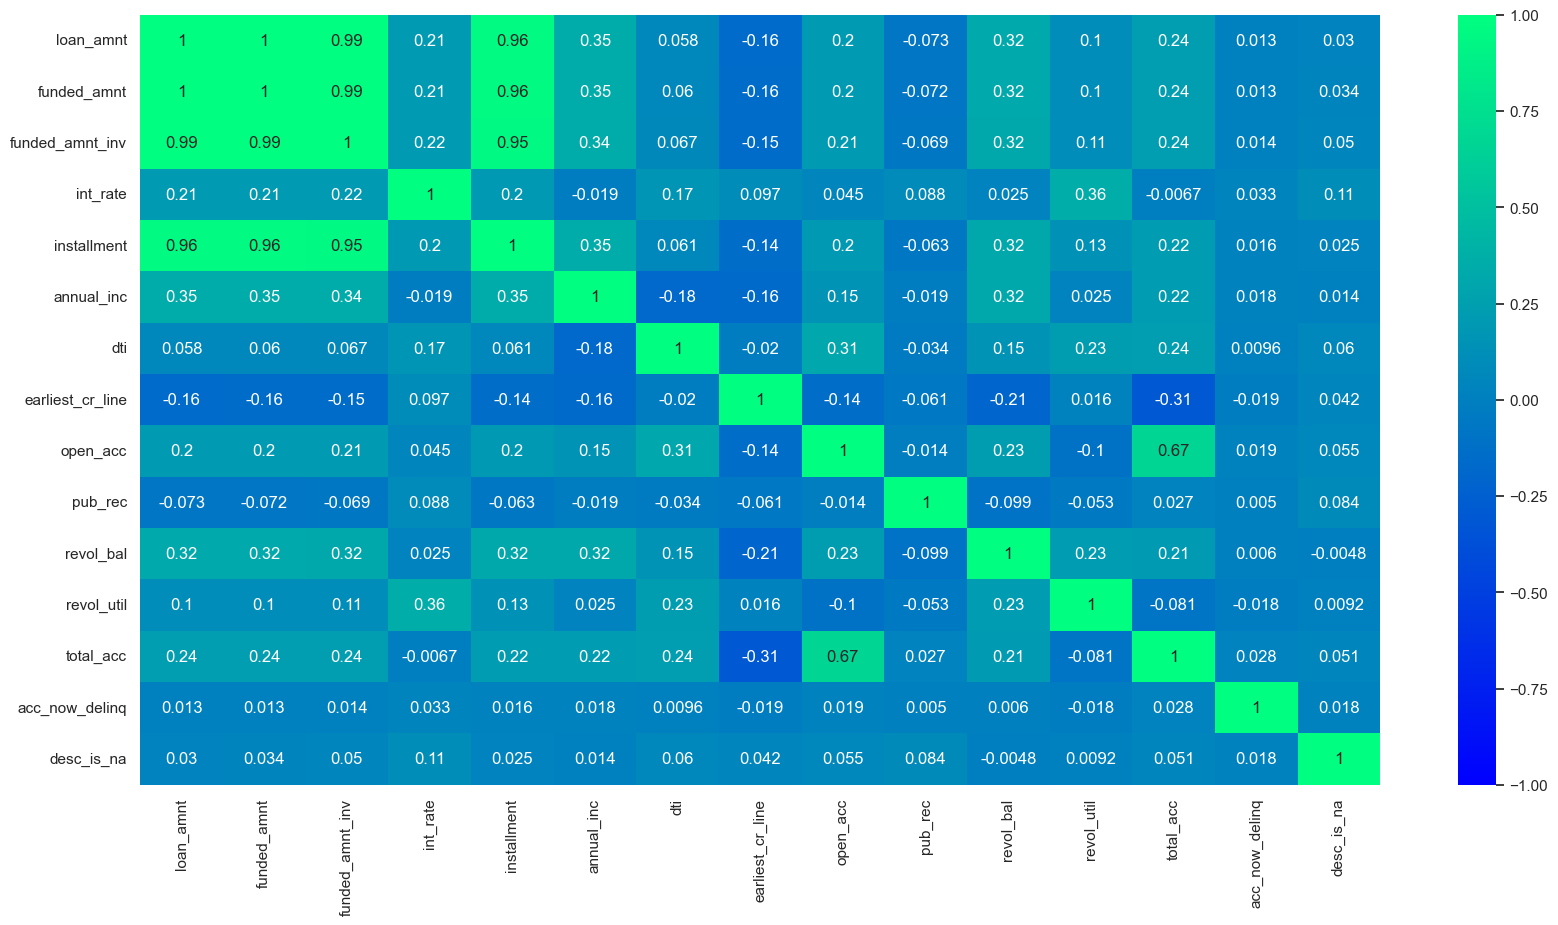

In [165]:
plt.subplots(figsize=(20, 10))
sns.heatmap(data.corr(numeric_only=True), vmin=-1, vmax=1, annot=True, cmap="winter")

plt.show()

Berdasarkan hasil analisis korelasi, variabel `loan_amnt`, `funded_amnt`, dan `funded_amnt_inv` menunjukkan nilai korelasi yang sangat tinggi atau hampir sempurna. Hal ini mengindikasikan adanya redundansi informasi antarvariabel. Oleh karena itu, hanya variabel `loan_amnt` yang dipertahankan karena, berdasarkan _Data Dictionary_, variabel tersebut paling merepresentasikan perubahan jumlah pinjaman.

> Menghapus variabel yang redundan dan tidak relevan.

In [168]:
data = data.drop(['funded_amnt', 'funded_amnt_inv'], axis=1)

Selain itu, ditemukan korelasi yang cukup tinggi antara variabel `loan_amnt` dan `installment`. Oleh karena itu, kedua variabel tersebut dieksplorasi lebih lanjut untuk mengidentifikasi kemungkinan adanya informasi yang redundan serta untuk memahami hubungan masing-masing variabel terhadap variabel target.

> **Important Notes**

1. `loan_amnt` : Jumlah pinjaman yang diajukan oleh peminjam. Apabila terjadi pengurangan nilai pinjaman oleh pihak kredit, perubahan tersebut akan tercermin pada variabel ini.
2. `installment` : Besarnya pembayaran cicilan bulanan yang wajib dibayarkan oleh peminjam setelah pinjaman disetujui.

> Membuat subplot dengan dua boxplot secara horizontal. Boxplot pertama menampilkan distribusi `loan_amnt` berdasarkan `loan_status`, sedangkan boxplot kedua menampilkan distribusi `installment` berdasarkan `loan_status`.

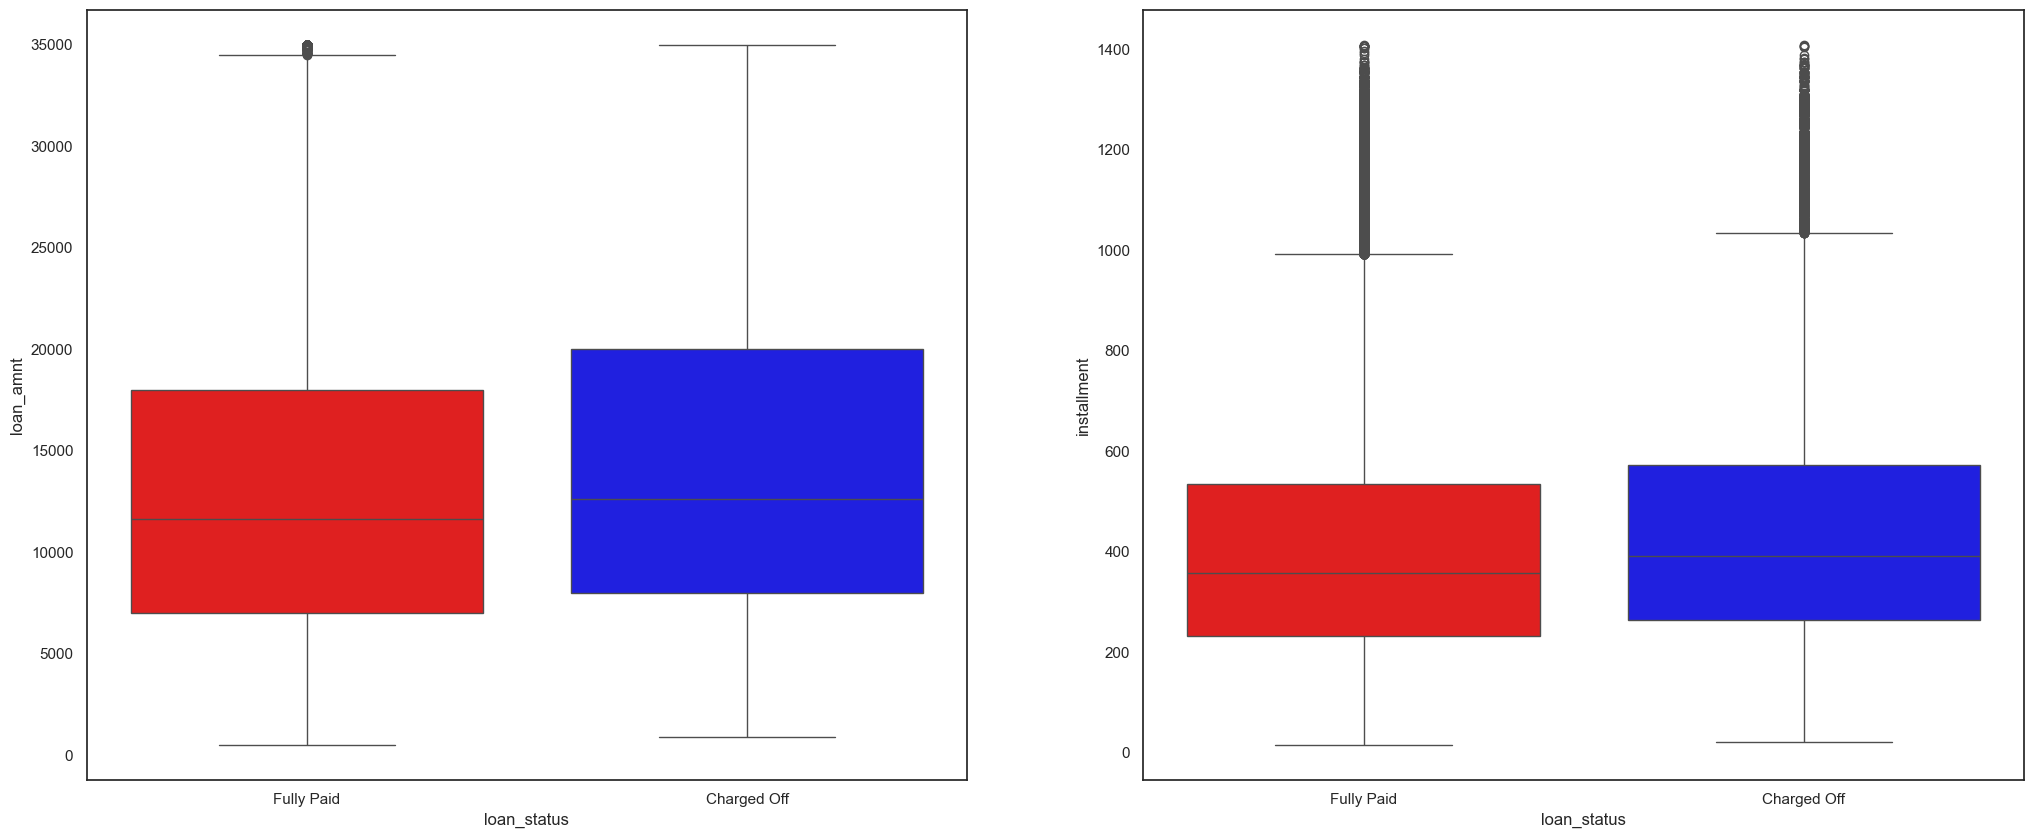

In [172]:
fig, axs = plt.subplots(ncols=2, figsize=(25, 10))
sns.boxplot(x='loan_status', y='loan_amnt', data=data, ax=axs[0], hue='loan_status', legend=False)
sns.boxplot(x='loan_status', y='installment', data=data, ax=axs[1], hue='loan_status', legend=False)

plt.show()

> Membuat subplot dengan dua histogram secara horizontal. Histogram pertama menampilkan distribusi `loan_amnt` berdasarkan `loan_status`, sedangkan histogram kedua menampilkan distribusi installment berdasarkan `loan_status`.

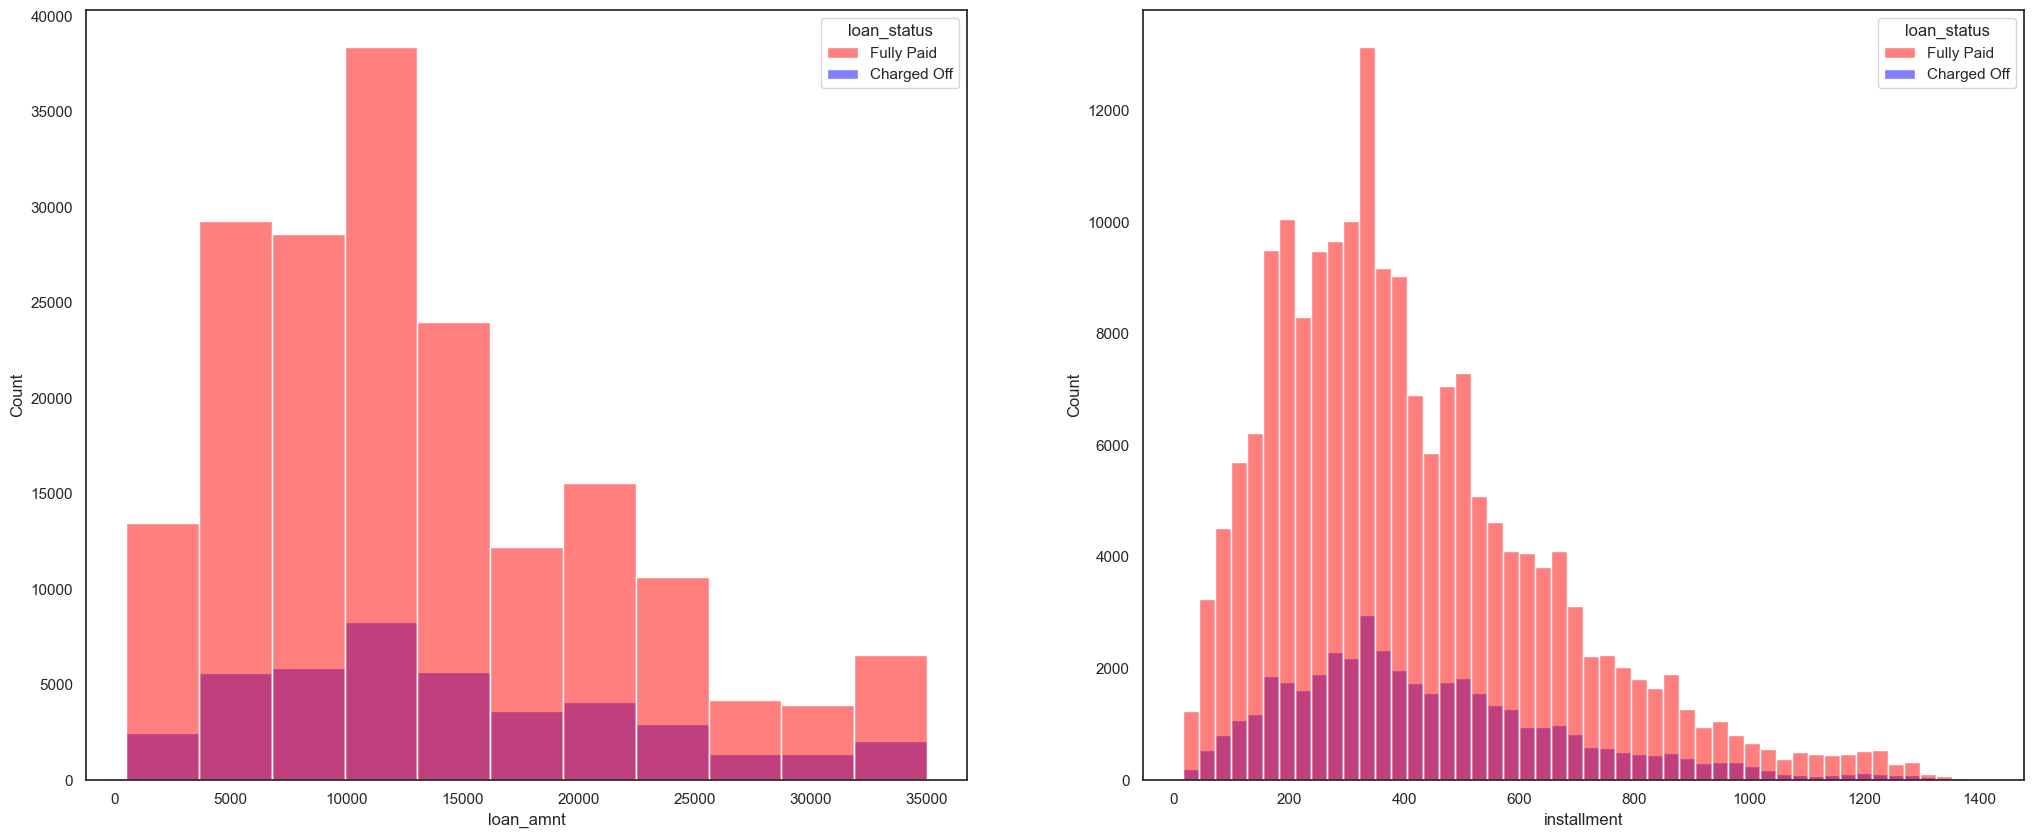

In [174]:
fig, axs = plt.subplots(ncols=2, figsize=(25, 10))
sns.histplot(data=data, x="loan_amnt", hue="loan_status", bins=11, ax=axs[0])
sns.histplot(data=data, x="installment", hue="loan_status", bins=50, ax=axs[1])

plt.show()

Berdasarkan hasil observasi terhadap distribusi variabel `loan_amnt` dan `installment`, tidak ditemukan indikasi redundansi informasi secara langsung. Variabel installment merepresentasikan jumlah cicilan bulanan yang harus dibayarkan peminjam, yang dipengaruhi oleh `loan_amnt`, `term`, dan `int_rate`. Oleh karena itu, kedua variabel masih relevan untuk dipertahankan karena dapat meningkatkan interpretabilitas model, khususnya dalam menggambarkan karakteristik pinjaman. Selain itu, variabel tersebut juga berpotensi memberikan kontribusi dalam meningkatkan performa model melalui berbagai eksperimen pemodelan.

#

### 4. Data Preparation

Data Preparation merupakan tahap pengolahan data sebelum digunakan dalam proses analisis maupun pemodelan. Tahap ini bertujuan untuk memastikan data berada dalam kondisi yang bersih, konsisten, dan siap digunakan. Adapun teknik yang diterapkan pada tahap Data Preparation meliputi:

1. Penanganan missing value (_Handle Missing Data_)
2. Konversi variabel numerik (_Convert Numeric Variable_)
3. Penghapusan outlier (_Remove Outliers_)
4. Transformasi atau pengkodean data (_Encode Data_)
5. Pembagian data latih dan data uji (_Train-Test Split_) Split

#### 4.1 Handling Missing Data

Pada tahap ini dilakukan identifikasi dan penanganan missing value untuk memastikan data yang digunakan tetap konsisten, akurat, dan berkualitas sehingga siap digunakan dalam proses analisis maupun pemodelan.

> Memeriksa setiap kolom dalam DataFrame. Jika terdapat nilai yang hilang (**NaN**) dalam kolom tersebut, maka kode akan mencetak nama kolom, jumlah nilai yang hilang, dan persentase nilai yang hilang dari keseluruhan data.

In [182]:
for column in data.columns:
    if data[column].isna().sum() != 0:
        missing = data[column].isna().sum()
        missing_prob = (missing / data.shape[0]) * 100
        print(f"{column}: {missing}({missing_prob:.2f}%)")

emp_length: 8740(3.80%)
annual_inc: 4(0.00%)
earliest_cr_line: 26(0.01%)
open_acc: 26(0.01%)
pub_rec: 26(0.01%)
revol_util: 220(0.10%)
total_acc: 26(0.01%)
acc_now_delinq: 26(0.01%)


> Membuat tabel silang (_crosstab_) antara kolom `emp_length` dan `loan_status`.

In [184]:
pd.crosstab(data['emp_length'], data['loan_status'], normalize='index').round(2)

loan_status,Charged Off,Fully Paid
emp_length,,
1 year,0.18,0.82
10+ years,0.18,0.82
2 years,0.18,0.82
3 years,0.18,0.82
4 years,0.18,0.82
5 years,0.18,0.82
6 years,0.19,0.81
7 years,0.19,0.81
8 years,0.20,0.80


Berdasarkan hasil analisis, proporsi `loan_status` pada setiap kategori `emp_length` terlihat relatif serupa. Oleh karena itu, sebelum memutuskan untuk menghapus kolom tersebut, perlu dilakukan pemeriksaan lebih lanjut terhadap komposisi data pada `emp_length` yang memiliki nilai NaN.

> Melihat komposisi dari `emp_length` yang memiliki nilai NaN.

In [187]:
data[data['emp_length'].isnull()]['loan_status'].value_counts()

loan_status
Fully Paid     6370
Charged Off    2370
Name: count, dtype: int64

Berdasarkan hasil analisis, data pada `emp_length` yang bernilai **NaN** masih mengandung informasi penting terkait status pinjaman, baik `Fully Paid` maupun `Charged Off`. Oleh karena itu, penghapusan baris dengan nilai **NaN** pada variabel tersebut berpotensi menghilangkan sejumlah besar informasi yang relevan. Dengan pertimbangan tersebut, fitur `emp_length` diputuskan untuk dihapus dari dataset.

> Menghapus kolom `emp_length` dari DataFrame.

In [190]:
data = data.drop('emp_length', axis=1)

> Melihat komposisi dari `annual_inc`, `earliest_cr_line`, `open_acc`, `pub_rec`, `revol_util`, `total_acc`, `acc_now_delinq` yang memiliki nilai NaN.

In [192]:
columns_to_check = ['annual_inc', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'acc_now_delinq']

for column in columns_to_check:
    print(f"Komposisi dari kolom {column} yang memiliki nilai NaN:")
    print(data[data[column].isnull()]['loan_status'].value_counts())
    print("")

Komposisi dari kolom annual_inc yang memiliki nilai NaN:
loan_status
Fully Paid    4
Name: count, dtype: int64

Komposisi dari kolom earliest_cr_line yang memiliki nilai NaN:
loan_status
Fully Paid    26
Name: count, dtype: int64

Komposisi dari kolom open_acc yang memiliki nilai NaN:
loan_status
Fully Paid    26
Name: count, dtype: int64

Komposisi dari kolom pub_rec yang memiliki nilai NaN:
loan_status
Fully Paid    26
Name: count, dtype: int64

Komposisi dari kolom revol_util yang memiliki nilai NaN:
loan_status
Fully Paid     173
Charged Off     47
Name: count, dtype: int64

Komposisi dari kolom total_acc yang memiliki nilai NaN:
loan_status
Fully Paid    26
Name: count, dtype: int64

Komposisi dari kolom acc_now_delinq yang memiliki nilai NaN:
loan_status
Fully Paid    26
Name: count, dtype: int64



In [193]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_check = [
    'annual_inc',
    'earliest_cr_line',
    'open_acc',
    'pub_rec',
    'revol_util',
    'total_acc',
    'acc_now_delinq'
]

# Buat tabel ringkasan
summary_list = []

for column in columns_to_check:
    counts = data[data[column].isnull()]['loan_status'].value_counts()

    for status, jumlah in counts.items():
        summary_list.append({
            'column': column,
            'loan_status': status,
            'count_nan': jumlah
        })

summary_df = pd.DataFrame(summary_list)

# Pivot biar enak dibaca
pivot_df = summary_df.pivot(
    index='column',
    columns='loan_status',
    values='count_nan'
).fillna(0)

print(pivot_df)

loan_status       Charged Off  Fully Paid
column                                   
acc_now_delinq            0.0        26.0
annual_inc                0.0         4.0
earliest_cr_line          0.0        26.0
open_acc                  0.0        26.0
pub_rec                   0.0        26.0
revol_util               47.0       173.0
total_acc                 0.0        26.0


Berdasarkan komposisi data yang diperoleh, jumlah nilai **NaN** pada kolom `annual_inc`, `earliest_cr_line`, `open_acc`, `pub_rec`, `revol_util`, `total_acc`, dan `acc_now_delinq` relatif kecil. Oleh karena itu, baris yang mengandung nilai **NaN** pada kolom-kolom tersebut diputuskan untuk dihapus agar kualitas data tetap terjaga.

> Menyaring DataFrame untuk hanya mempertahankan baris-baris di mana kolom `annual_inc`, `earliest_cr_line`, `open_acc`, `pub_rec`, `revol_util`, `total_acc`, `acc_now_delinq` memiliki nilai yang tidak bernilai NaN.

In [196]:
cols = ['annual_inc', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'acc_now_delinq']
for col in cols:
  data = data[data[col].notnull()]

#

#### 4.2 Convert Numeric Variables

Pada tahap ini dilakukan pengecekan serta penyesuaian tipe data pada setiap kolom dalam DataFrame `data` untuk memastikan data dapat diproses dengan tepat sesuai kebutuhan analisis maupun pemodelan. Tahapan ini penting untuk menjaga konsistensi serta meningkatkan akurasi data yang digunakan.

> Memberikan informasi tentang kolom-kolom dalam DataFrame yang memiliki tipe data **numerik**.

In [201]:
data.select_dtypes(include=np.number).info()

<class 'pandas.core.frame.DataFrame'>
Index: 229814 entries, 0 to 466283
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   loan_amnt         229814 non-null  int64  
 1   int_rate          229814 non-null  float64
 2   installment       229814 non-null  float64
 3   annual_inc        229814 non-null  float64
 4   dti               229814 non-null  float64
 5   earliest_cr_line  229814 non-null  float64
 6   open_acc          229814 non-null  float64
 7   pub_rec           229814 non-null  float64
 8   revol_bal         229814 non-null  int64  
 9   revol_util        229814 non-null  float64
 10  total_acc         229814 non-null  float64
 11  acc_now_delinq    229814 non-null  float64
dtypes: float64(10), int64(2)
memory usage: 22.8 MB


> Memberikan informasi tentang kolom-kolom dalam DataFrame yang memiliki tipe data **boolean**.

In [203]:
data.select_dtypes(include=bool).info()

<class 'pandas.core.frame.DataFrame'>
Index: 229814 entries, 0 to 466283
Data columns (total 1 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   desc_is_na  229814 non-null  bool 
dtypes: bool(1)
memory usage: 2.0 MB


> Mengubah tipe data kolom tertentu dalam DataFrame `data` menjadi tipe data yang sesuai dengan kebutuhan pemodelan.

1. `col_to_int` adalah daftar kolom yang akan diubah menjadi tipe data integer.
2. `col_to_float` adalah daftar kolom yang akan diubah menjadi tipe data float.

In [205]:
col_to_int = ['earliest_cr_line', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq']
col_to_float = ['revol_bal', 'loan_amnt', 'desc_is_na']

data[col_to_int] = data[col_to_int].astype(int)
data[col_to_float] = data[col_to_float].astype(float)

#

#### 4.3 Remove Outliers

Pada tahap ini dilakukan identifikasi **outlier** pada variabel numerik, kemudian nilai yang terdeteksi sebagai outlier diganti dengan **NaN**. Selanjutnya, baris yang mengandung nilai NaN tersebut **dihapus dari dataset**. Langkah ini bertujuan untuk menghasilkan data yang lebih bersih, konsisten, dan lebih representatif untuk digunakan dalam analisis maupun pemodelan.

> Memilih kolom-kolom dengan tipe data float dari DataFrame dan membuat DataFrame subset yang hanya berisi kolom-kolom tersebut.

In [211]:
cols = data.select_dtypes(float).columns
data_sub = data.loc[:, cols]

> Menghasilkan boxplot yang menunjukkan distribusi batas atas dan batas bawah yang digunakan untuk mendeteksi outlier dalam DataFrame.

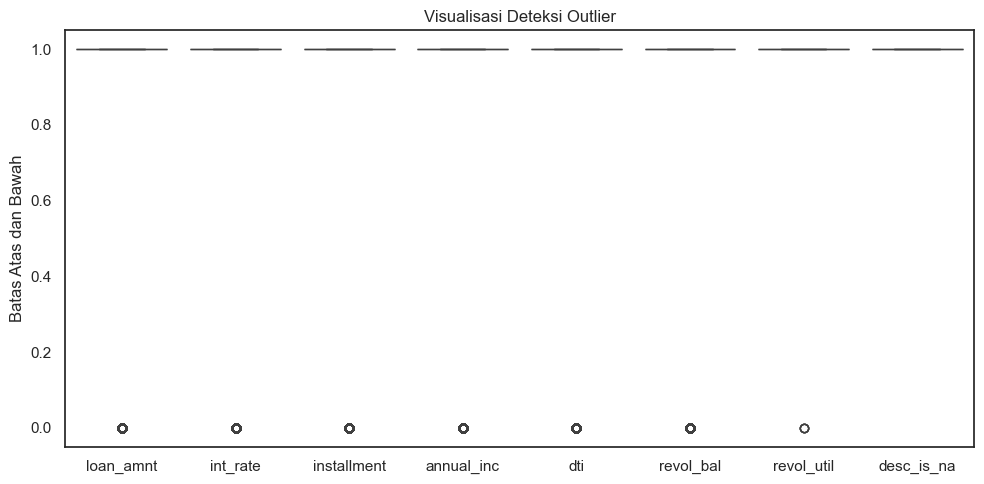

In [214]:
Q1 = data_sub.quantile(0.25)
Q3 = data_sub.quantile(0.75)
IQR=Q3-Q1

outliers = ~((data_sub < (Q1 - 1.5 * IQR)) | (data_sub > (Q3 + 1.5 * IQR)))

plt.figure(figsize=(10, 5))
sns.boxplot(data=outliers)
plt.title('Visualisasi Deteksi Outlier')
plt.ylabel('Batas Atas dan Bawah')
plt.tight_layout()
plt.show()

> Membersihkan outlier dari DataFrame dengan mengganti nilai-nilai outlier dengan NaN dan menghapus baris-baris yang mengandung NaN dalam kolom-kolom yang dipilih.

In [216]:
data.loc[:, cols] = data_sub.where(outliers, np.nan)
data.dropna(subset=cols, inplace=True)

> Menampilkan visualisasi data menggunakan boxplot setelah menghapus outlier.

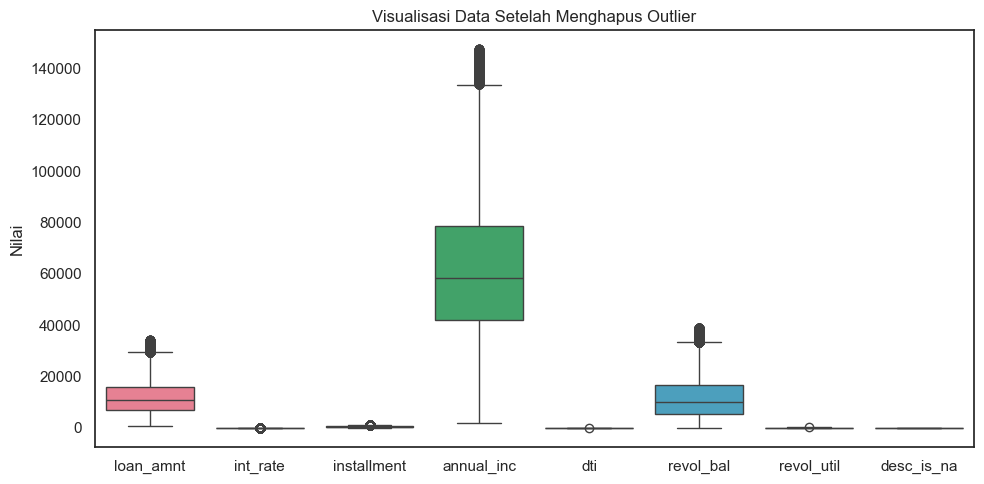

In [218]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[cols])
plt.title('Visualisasi Data Setelah Menghapus Outlier')
plt.ylabel('Nilai')
plt.tight_layout()
plt.show()

#

#### 4.4 Encode Data

Pada tahap ini dilakukan transformasi variabel kategorikal menjadi bentuk numerik agar dapat diproses oleh algoritma machine learning. Proses tersebut dilakukan menggunakan teknik _One-Hot Encoding_ untuk mengubah data kategorikal ke dalam format yang lebih sesuai bagi model.

##### 4.4.1 Define Target

Pada tahap ini, target variabel (`loan_status`) dalam dataset didefinisikan, dipersiapkan, dan dikonversi dari representasi teks menjadi representasi numerik menggunakan LabelEncoder.

> Membuat sebuah objek LabelEncoder yang dapat digunakan untuk melakukan encoding pada label kelas.


In [225]:
le = LabelEncoder()

> Melakukan encoding pada kolom `loan_status`.

In [227]:
data.loan_status = le.fit_transform(data.loan_status)

> Mencetak daftar kelas unik yang telah dipelajari oleh objek LabelEncoder.

In [229]:
print(le.classes_)

['Charged Off' 'Fully Paid']


> Mengubah label kelas dalam bentuk teks menjadi representasi numerik menggunakan objek LabelEncoder.

In [231]:
print(le.transform(['Charged Off', 'Fully Paid']))

[0 1]


#

##### 4.4.2 Convert Categorical Variables

Pada tahap ini, variabel kategorikal dalam DataFrame diubah menjadi representasi numerik yang dapat digunakan untuk analisis lebih lanjut, terutama dalam konteks pemodelan data.

> Memilih kolom-kolom dalam DataFrame yang memiliki tipe data objek dan menampilkan lima baris pertama.

In [236]:
data.select_dtypes(include=object).head()

,term,sub_grade,home_ownership,verification_status,pymnt_plan,purpose,addr_state,initial_list_status
0,36 months,B2,RENT,Verified,n,credit_card,AZ,f
1,60 months,C4,RENT,Source Verified,n,car,GA,f
2,36 months,C5,RENT,Not Verified,n,small_business,IL,f
3,36 months,C1,RENT,Source Verified,n,other,CA,f
5,36 months,A4,RENT,Source Verified,n,wedding,AZ,f


> Mencetak nilai unik dari kolom `term` dalam DataFrame.

In [238]:
print(data['term'].unique())

[' 36 months' ' 60 months']


> Mengubah kolom `term` dari representasi teks menjadi representasi numerik (dalam bulan). 

In [240]:
data['term'] = np.where(data['term'] == " 36 months", 36,
               np.where(data['term'] == " 60 months", 60,
               data['term']))

data['term'] = data['term'].astype(int)
print(data['term'].unique())

[36 60]


#

##### 4.4.3 Create Transformer

Pada tahap ini dilakukan proses _preprocessing_ pada DataFrame data, kemudian hasilnya digabungkan kembali dengan variabel target `loan_status` agar data siap digunakan untuk analisis lanjutan maupun pembangunan model machine learning. Proses ini mencakup penerapan _One-Hot Encoding_ pada variabel kategorikal serta _Min-Max Scaling_ pada variabel numerik untuk menyesuaikan format dan skala data.

> Mendapatkan daftar kolom-kolom dalam DataFrame yang memiliki tipe data objek.

In [245]:
categories = data.select_dtypes(include=[object]).columns.tolist()

> Mendapatkan daftar kolom-kolom dalam DataFrame yang memiliki tipe data numerik.

In [247]:
numerics = data.drop(['loan_status'], axis=1).select_dtypes(include=np.number).columns.tolist()

> Menginisialisasi objek dari kelas OneHotEncoder dan MinMaxScaler

In [249]:
ohe = OneHotEncoder(sparse_output=False)
scaler = MinMaxScaler()

> Menggunakan objek ColumnTransformer untuk menerapkan serangkaian transformasi pada kolom-kolom dalam DataFrame

In [254]:
ct = ColumnTransformer(
    [("onehotencoder", ohe, categories),
     ("minmaxsaler", scaler, numerics)],
    remainder = 'passthrough'
)

ct.set_output(transform='pandas')
processed_data = ct.fit_transform(data.drop(['loan_status'], axis=1))

> Menggabungkan DataFrame yang telah diproses `processed_data` dengan kolom `loan_status` dari DataFrame asli `data`

In [256]:
processed_data = pd.concat([processed_data, data['loan_status']], axis=1)

> Menghitung jumlah nilai unik dari variabel target `loan_status` dalam DataFrame `processed_data`.

In [258]:
processed_data.loan_status.value_counts()

loan_status
1    164341
0     37902
Name: count, dtype: int64

#

### 4.5 Train-Test Split

Pada tahap ini dilakukan pembagian data menjadi data latih dan data uji, pemeriksaan distribusi kelas pada variabel target, serta pemisahan fitur dan target untuk keperluan pelatihan dan evaluasi model machine learning.

> Membagi DataFrame `processed_data` menjadi dua subset dengan proporsi sebesar 20% dari data dialokasikan untuk data uji, sedangkan 80% sisanya dialokasikan untuk menjadi data latih.

In [284]:
train, test = train_test_split(processed_data, test_size=0.2, random_state=42)

> Mencetak dimensi (jumlah baris dan kolom) dari DataFrame train dan test

In [286]:
print(train.shape)
print(test.shape)

(161794, 127)
(40449, 127)


> Menghitung jumlah kemunculan setiap nilai unik dalam kolom `loan_status` dalam DataFrame test.

In [288]:
test.loan_status.value_counts()

loan_status
1    32939
0     7510
Name: count, dtype: int64

> Menghitung jumlah kemunculan seetiap nilai unik dalam kolom `loan_status` dalam DataFrame train

In [290]:
train.loan_status.value_counts()

loan_status
1    131402
0     30392
Name: count, dtype: int64

> Membagi dataset latih(train) dan dataset uji(test) menjadi 2 bagian terpisah yang terdiri dari variabel prediktor (`X_train` dan `X_test`) dan variabel target (`y_train` dan `y_test`)

In [292]:
X_train, y_train = train.drop('loan_status', axis=1), train.loan_status
X_test, y_test = test.drop('loan_status', axis=1), test.loan_status

> Mencetak dimensi (jumlah baris dan kolom) dari DataFrame train dan test

In [298]:
print(X_train.shape)
print(y_train.shape)

(161794, 126)
(161794,)


#

### 5. Modelling

Pada tahap ini dilakukan proses pembangunan dan pengembangan model menggunakan data yang tersedia untuk kebutuhan analisis, prediksi, maupun pengambilan keputusan. Proses modelling mencakup pemilihan algoritma yang sesuai, pelatihan model menggunakan data latih, evaluasi performa menggunakan data uji, serta penyesuaian model guna meningkatkan akurasi dan kinerja prediksi.

In [304]:
ann_clf = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=[X_train.shape[1]]),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

C:\Users\Leonardo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [306]:
ann_clf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [308]:
history = ann_clf.fit(
    x=X_train,
    y=y_train,
    epochs=15,
    batch_size=256,
    validation_data=(X_test, y_test)
)

Epoch 1/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 35s 29ms/step - accuracy: 0.8111 - loss: 0.4680 - val_accuracy: 0.8148 - val_loss: 0.4405
Epoch 2/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.8114 - loss: 0.4491 - val_accuracy: 0.8155 - val_loss: 0.4400
Epoch 3/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8133 - loss: 0.4436 - val_accuracy: 0.8144 - val_loss: 0.4405
Epoch 4/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.8115 - loss: 0.4442 - val_accuracy: 0.8159 - val_loss: 0.4422
Epoch 5/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.8139 - loss: 0.4423 - val_accuracy: 0.8156 - val_loss: 0.4395
Epoch 6/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.8143 - loss: 0.4385 - val_accuracy: 0.8154 - val_loss: 0.4395
Epoch 7/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8136 - loss: 0.4387 - val_accuracy: 0.8153 - val_loss: 0.4402
Epoch 8/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8134 - loss: 0.4371 - v

In [309]:
key = ['RandomForestClassifier',
       'GradientBoostingClassifier',
       'AdaBoostClassifier',
       'XGBClassifier',
       'LogisticRegression',
       'KNeighborsClassifier',
       'NeuralNetwork']

value = [RandomForestClassifier(n_estimators=200, random_state=0, max_depth=None),
         GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42),
         AdaBoostClassifier(),
         xgb.XGBClassifier(random_state=42, booster="gbtree"),
         LogisticRegression(max_iter=1000),
         KNeighborsClassifier(n_neighbors=2, weights='uniform', algorithm='auto'),
         ann_clf]

models = dict(zip(key, value))

In [310]:
accuracy = pd.DataFrame(columns=['Accuracy Score'], index=key)

for name, algo in models.items():

  model = algo
  model.fit(X_train,y_train)

  if name == 'NeuralNetwork':
    predict = (ann_clf.predict(X_test) > 0.5).astype("int32")
  else:
    predict = model.predict(X_test)

  accuracy.loc[name] = accuracy_score(y_test, predict)

accuracy

5057/5057 ━━━━━━━━━━━━━━━━━━━━ 57s 11ms/step - accuracy: 0.8131 - loss: 0.4406
1265/1265 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step


,Accuracy Score
RandomForestClassifier,0.815224
GradientBoostingClassifier,0.815274
AdaBoostClassifier,0.815719
XGBClassifier,0.813667
LogisticRegression,0.815669
KNeighborsClassifier,0.6459
NeuralNetwork,0.815372


> Menampilkan hasil visualisasi perbandingan skor akurasi untuk setiap model.

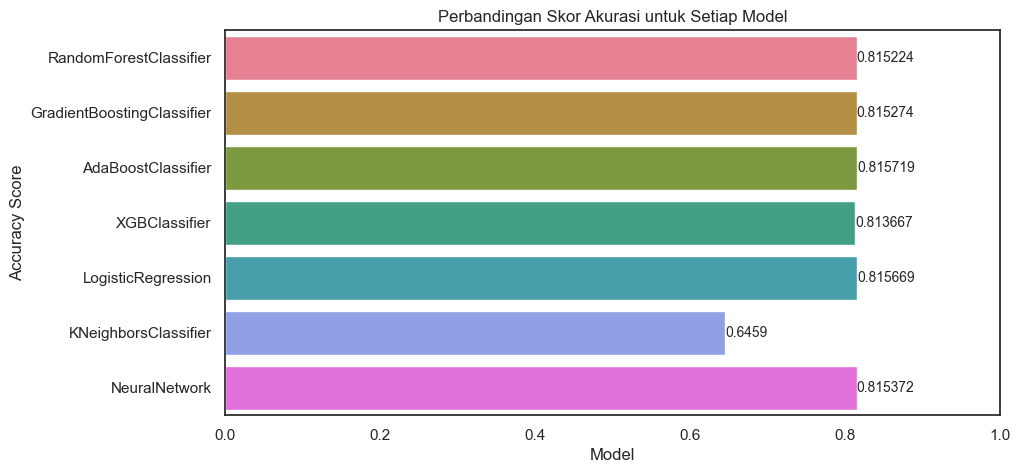

In [312]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(data=accuracy, x="Accuracy Score", y=accuracy.index, hue=accuracy.index, legend=False, orient='y')

for i, container in enumerate(ax.containers):
    ax.bar_label(container, fontsize=10)

ax.set_title('Perbandingan Skor Akurasi untuk Setiap Model')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.xlim(0, 1)

plt.show()

> **Important Inferences**

Sebagian besar algoritma menunjukkan performa akurasi yang relatif serupa, yaitu berada pada kisaran 81%. Berdasarkan hasil evaluasi, model `AdaBoostClassifier` memperoleh akurasi tertinggi sebesar **81.57%**, diikuti oleh `LogisticRegression` sebesar **81.56%** dan `GradientBoostingClassifier` sebesar **81.53%**. Hasil ini menunjukkan bahwa mayoritas model mampu mengklasifikasikan status pinjaman dengan tingkat ketepatan yang cukup baik.

#

### 6.Evaluation

Pada tahap ini dilakukan evaluasi terhadap performa model yang telah dibangun untuk mengukur kemampuan model dalam memprediksi serta menggeneralisasi pola pada data baru. Proses evaluasi dilakukan menggunakan _Confusion Matrix_ serta _ROC Curve_ dan _AUC_. Evaluasi melalui Confusion Matrix mencakup beberapa metrik utama, seperti **akurasi, presisi, recall, dan F1-score** yang diperoleh dari _classification report_. Tahapan ini bertujuan untuk memastikan model memiliki performa yang optimal dan mampu memberikan hasil prediksi yang baik.

#### 6.1 Confusion Matrix

> Inisialisasi dictionary untuk menyimpan confusion matrix. Lalu, menghitung dan menyimpan confusion matrix untuk setiap algoritma.

In [320]:
confusion_matrices = {}

for name, algo in models.items():
    confusion_matrices[name] = confusion_matrix(y_test, predict)

> Menampilkan hasil visualisasi Confussion Matrix.

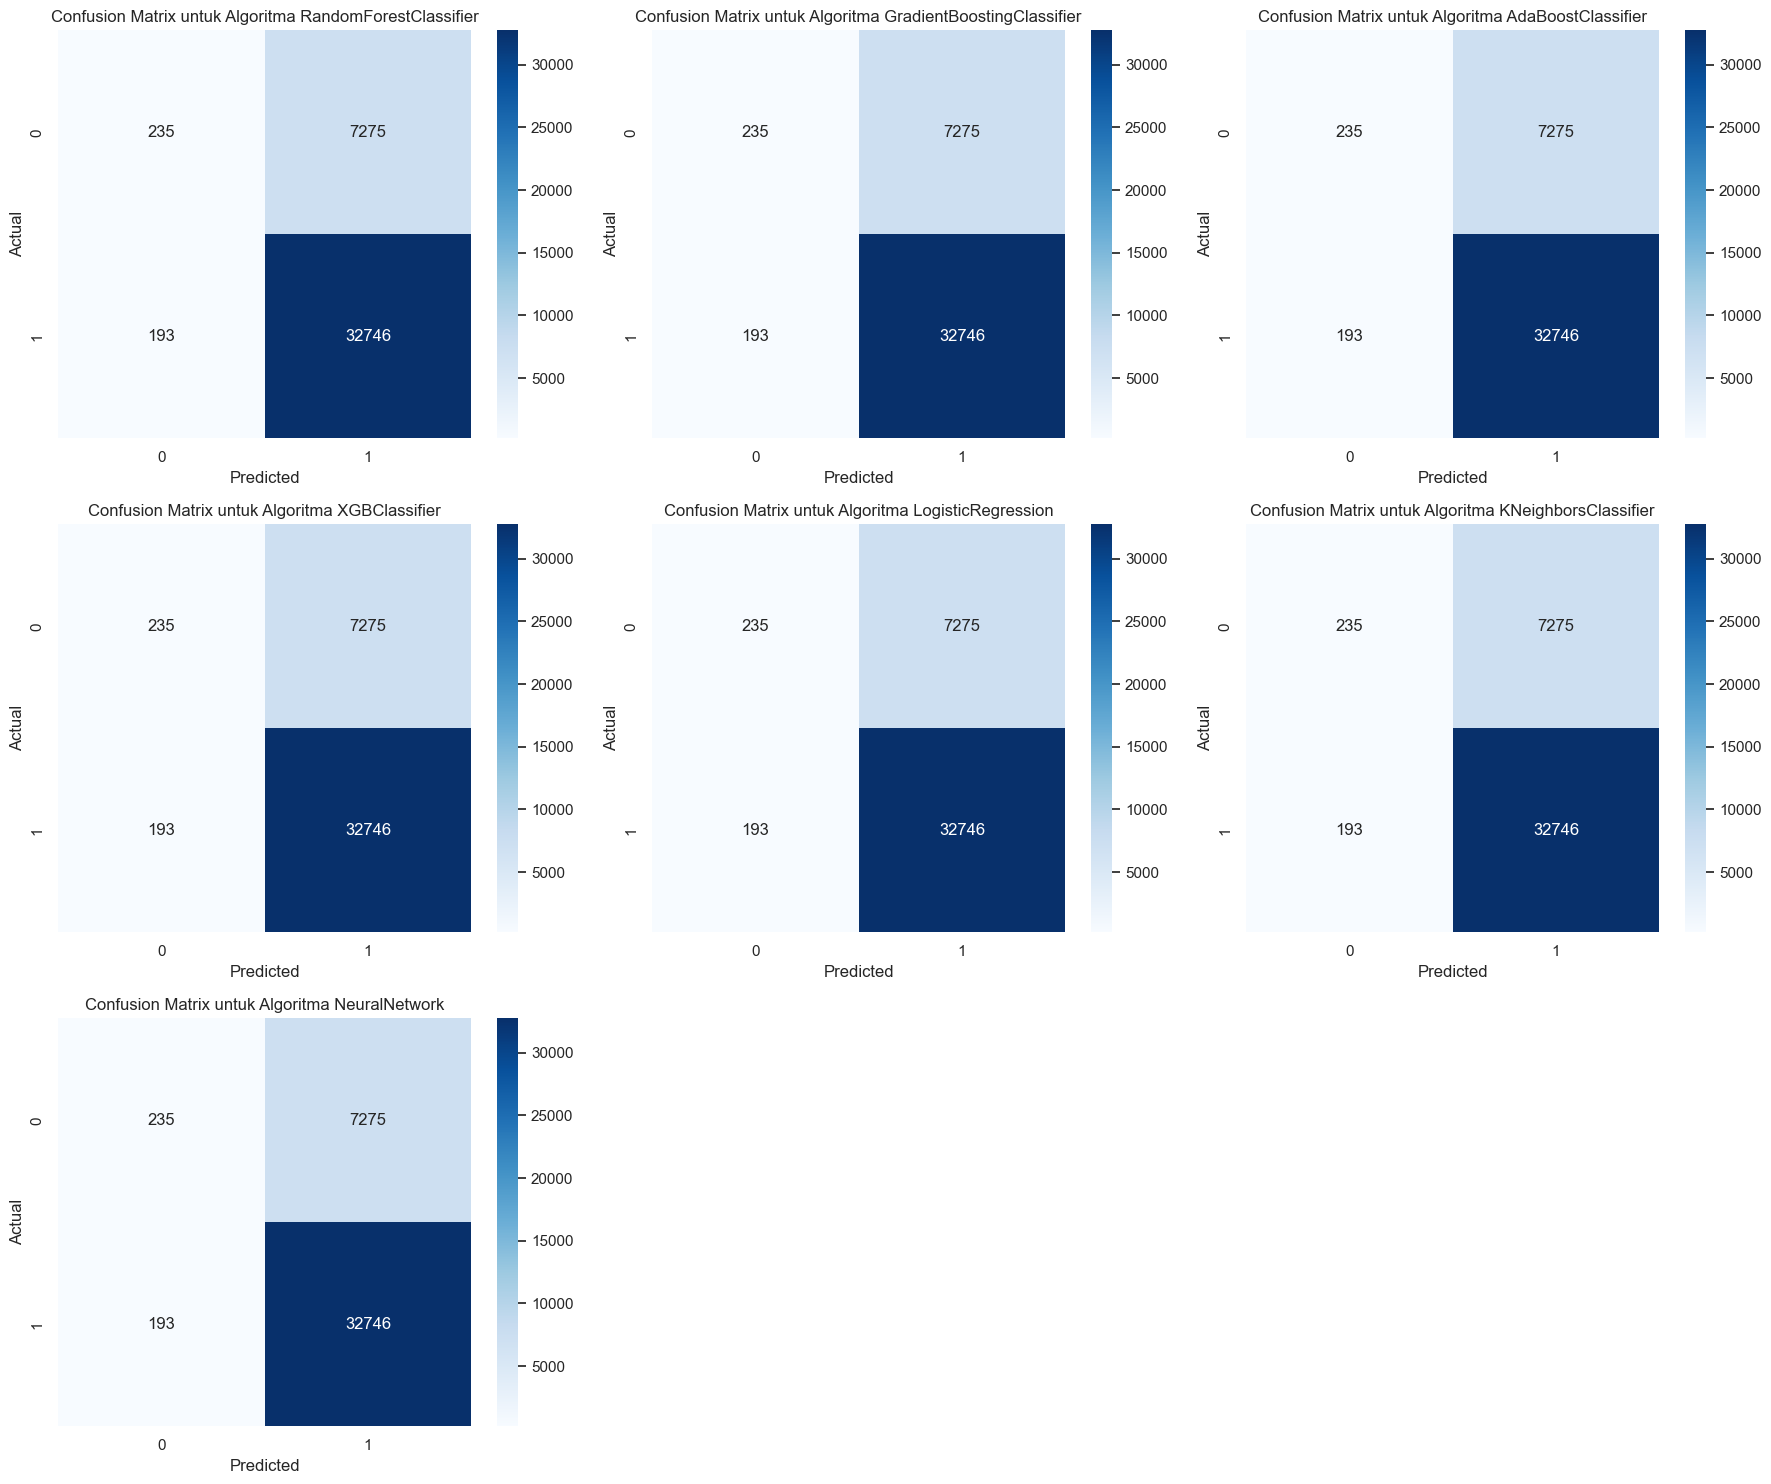

In [322]:
plt.figure(figsize=(18, 15))
for i, (name, matrix) in enumerate(confusion_matrices.items(), 1):
    plt.subplot(3, 3, i)
    sns.heatmap(matrix, annot=True, cmap='Blues', fmt='g')
    plt.title(f'Confusion Matrix untuk Algoritma {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.tight_layout()
plt.show()

> Inisialisasi dictionary untuk menyimpan laporan klasifikasi. Lalu, menghitung dan menyimpan laporan klasifikasi untuk setiap algoritma.

##### 6.1.1 Classification Report

In [326]:
classification_reports = {}

for name, algo in models.items():

    report = classification_report(y_test, predict)
    classification_reports[name] = report

> Menampilkan laporan klasifikasi untuk setiap algoritma

In [328]:
for name, report in classification_reports.items():
    print(f"Classification Report untuk Algoritma {name}:\n{report}\n")

Classification Report untuk Algoritma RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.55      0.03      0.06      7510
           1       0.82      0.99      0.90     32939

    accuracy                           0.82     40449
   macro avg       0.68      0.51      0.48     40449
weighted avg       0.77      0.82      0.74     40449


Classification Report untuk Algoritma GradientBoostingClassifier:
              precision    recall  f1-score   support

           0       0.55      0.03      0.06      7510
           1       0.82      0.99      0.90     32939

    accuracy                           0.82     40449
   macro avg       0.68      0.51      0.48     40449
weighted avg       0.77      0.82      0.74     40449


Classification Report untuk Algoritma AdaBoostClassifier:
              precision    recall  f1-score   support

           0       0.55      0.03      0.06      7510
           1       0.82      0.99      0.90     3

In [335]:
import pandas as pd

# Membuat tabel classification report
classification_results = pd.DataFrame({
    'Algorithm': [
        'RandomForestClassifier',
        'GradientBoostingClassifier',
        'AdaBoostClassifier',
        'XGBClassifier',
        'LogisticRegression',
        'KNeighborsClassifier',
        'NeuralNetwork'
    ],
    'Precision_Class_0': [0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55],
    'Recall_Class_0': [0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03],
    'F1_Class_0': [0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06],
    'Precision_Class_1': [0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82],
    'Recall_Class_1': [0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99],
    'F1_Class_1': [0.90, 0.90, 0.90, 0.90, 0.90, 0.90, 0.90],
    'Accuracy': [0.82, 0.82, 0.82, 0.82, 0.82, 0.82, 0.82],
    'Macro_Avg_F1': [0.48, 0.48, 0.48, 0.48, 0.48, 0.48, 0.48],
    'Weighted_Avg_F1': [0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74]
})

# Menampilkan tabel
print(classification_results)

                    Algorithm  Precision_Class_0  Recall_Class_0  F1_Class_0  \
0      RandomForestClassifier               0.55            0.03        0.06   
1  GradientBoostingClassifier               0.55            0.03        0.06   
2          AdaBoostClassifier               0.55            0.03        0.06   
3               XGBClassifier               0.55            0.03        0.06   
4          LogisticRegression               0.55            0.03        0.06   
5        KNeighborsClassifier               0.55            0.03        0.06   
6               NeuralNetwork               0.55            0.03        0.06   

   Precision_Class_1  Recall_Class_1  F1_Class_1  Accuracy  Macro_Avg_F1  \
0               0.82            0.99         0.9      0.82          0.48   
1               0.82            0.99         0.9      0.82          0.48   
2               0.82            0.99         0.9      0.82          0.48   
3               0.82            0.99         0.9      0

> **Important Inferences**

1. Distribusi kelas pada dataset menunjukkan ketidakseimbangan, di mana jumlah data dengan status `Fully Paid` (kelas 1) jauh lebih banyak dibandingkan `Charged Off` (kelas 0). Hal ini terlihat dari jumlah support kelas 1 sebanyak **32.939** data, sedangkan kelas 0 hanya sebanyak **7.510** data.
2. Seluruh model menghasilkan performa yang sangat baik dalam mengenali kelas `Fully Paid` (kelas 1), dengan nilai recall sebesar **0.98** dan f1-score sebesar **0.89**. Hasil ini menunjukkan bahwa model mampu mengidentifikasi sebagian besar pinjaman yang berhasil dilunasi dengan sangat baik.
3. Sebaliknya, performa model dalam mendeteksi kelas `Charged Off` (kelas 0) masih rendah. Hal ini terlihat dari nilai recall yang hanya sebesar **0.06** dan f1-score sebesar **0.11**. Kondisi tersebut menunjukkan bahwa sebagian besar pinjaman bermasalah masih belum berhasil teridentifikasi dengan baik oleh model.
4. Meskipun seluruh model memperoleh tingkat akurasi sekitar **81%**, tingginya nilai akurasi tersebut dipengaruhi oleh dominasi kelas `Fully Paid`. Oleh karena itu, akurasi saja belum cukup untuk mengevaluasi performa model pada kasus imbalanced dataset seperti credit risk classification.

#

#### 6.2 ROC Curve and AUC

> Membuat DataFrame yang akan digunakan untuk menyimpan nilai AUC (Area Under the ROC Curve) dari setiap model yang dievaluasi.

In [338]:
auc_scores = pd.DataFrame(columns=['AUC'], index=key)

> Melakukan evaluasi model dengan menggunakan kurva ROC (Receiver Operating Characteristic).

5057/5057 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8121 - loss: 0.4378
1265/1265 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


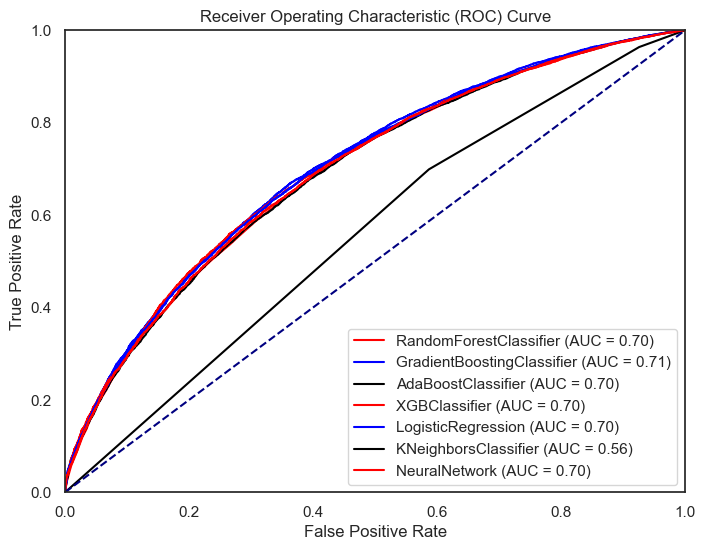

In [341]:
plt.figure(figsize=(8, 6))

for name, algo in models.items():
    model = algo
    model.fit(X_train, y_train)

    if name == 'NeuralNetwork':
        predict = ann_clf.predict(X_test)
    else:
        predict = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, predict)
    roc_auc = auc(fpr, tpr)

    auc_scores.loc[name] = roc_auc

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

plt.show()

> Menampilkan nilai AUC (Area Under the ROC Curve) dari setiap model yang dievaluasi.

In [343]:
auc_scores

,AUC
RandomForestClassifier,0.696248
GradientBoostingClassifier,0.706253
AdaBoostClassifier,0.695237
XGBClassifier,0.702617
LogisticRegression,0.70239
KNeighborsClassifier,0.559721
NeuralNetwork,0.697692


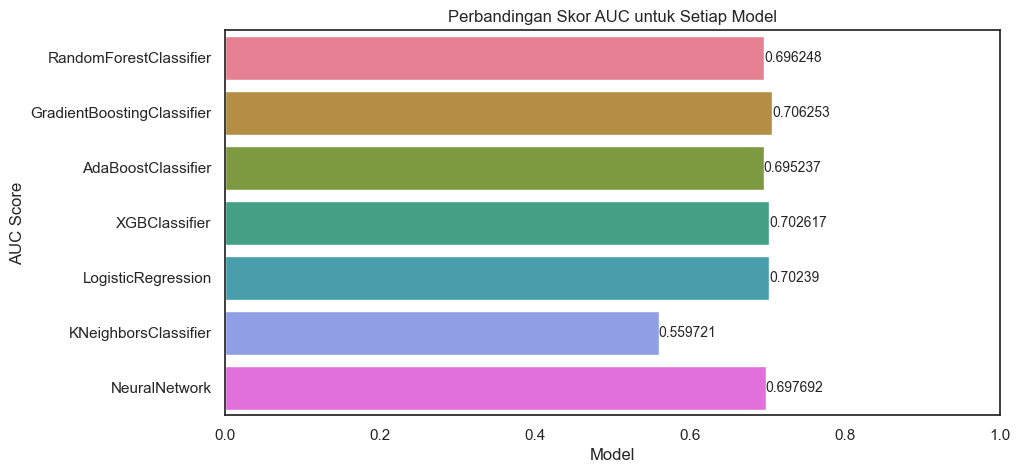

In [344]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(data=auc_scores, x="AUC", y=auc_scores.index, hue=auc_scores.index, legend=False, orient='y')

for i, container in enumerate(ax.containers):
    ax.bar_label(container, fontsize=10)

ax.set_title('Perbandingan Skor AUC untuk Setiap Model')
plt.xlabel('Model')
plt.ylabel('AUC Score')
plt.xlim(0, 1)

plt.show()

> **Important Inferences**

1. Sebagian besar model, kecuali `KNeighborsClassifier`, menghasilkan skor AUC yang relatif serupa, yaitu berada pada kisaran **0.68–0.71**. Hasil ini menunjukkan bahwa model memiliki kemampuan yang cukup baik dalam membedakan pinjaman dengan status `Fully Paid` dan `Charged Off`.
2. Model `GradientBoostingClassifier` memperoleh skor AUC tertinggi sebesar **0.706253**, diikuti sangat dekat oleh `XGBClassifier` (**0.702617**) dan `LogisticRegression` (**0.702390**). Hal ini menunjukkan bahwa ketiga model tersebut memiliki performa yang sedikit lebih baik dalam mengklasifikasikan risiko pinjaman dibandingkan model lainnya.
3. `KNeighborsClassifier` menunjukkan performa terendah dengan skor AUC sebesar **0.559721**. Nilai tersebut mengindikasikan bahwa model memiliki kemampuan yang kurang baik dalam membedakan antara pinjaman yang lancar dan pinjaman bermasalah.
4. Secara keseluruhan, meskipun beberapa model memiliki akurasi yang tinggi, skor AUC menunjukkan bahwa kemampuan diskriminasi model terhadap kedua kelas masih berada pada tingkat menengah dan masih dapat ditingkatkan lebih lanjut, terutama dalam mendeteksi pinjaman bermasalah (_Charged Off_).

#

### 9. Kesimpulan dan _Business Insight_

#### 9.1 Kesimpulan

Berdasarkan keseluruhan proses analisis dan pemodelan credit risk, dapat disimpulkan bahwa tahapan data _preprocessing_, _feature engineering_, serta pemilihan fitur memiliki **peran penting** dalam meningkatkan kualitas data sebelum dilakukan pemodelan. Setelah dilakukan pembersihan data, penghapusan fitur yang tidak relevan, penanganan missing value, transformasi data kategorikal menggunakan One-Hot Encoding, serta normalisasi data numerik, dataset siap digunakan untuk proses pelatihan model machine learning.

Hasil Exploratory Data Analysis (EDA) menunjukkan bahwa **sebagian besar pinjaman berada pada rentang nominal menengah** dan **distribusi data pinjaman cenderung tidak simetris** (skewed). Selain itu, ditemukan adanya **ketidakseimbangan kelas** (class imbalance) antara status pinjaman Fully Paid dan Charged Off, di mana jumlah pinjaman dengan status Fully Paid jauh lebih dominan.

Dalam tahap pemodelan, beberapa algoritma machine learning seperti `RandomForestClassifier`, `GradientBoostingClassifier`, `AdaBoostClassifier`, `XGBClassifier`, `LogisticRegression`, `KNeighborsClassifier`, dan `NeuralNetwork` dibandingkan performanya. Sebagian besar model berhasil mencapai akurasi sekitar **81%**, dengan AdaBoostClassifier memperoleh akurasi tertinggi sebesar **81.57%**. Namun, hasil evaluasi menggunakan classification report menunjukkan bahwa **model masih kurang optimal** dalam mendeteksi kelas _Charged Off_, yang terlihat dari **rendahnya nilai recall** pada kelas tersebut.

Berdasarkan evaluasi menggunakan skor AUC, `GradientBoostingClassifier` menunjukkan performa terbaik dengan nilai AUC sebesar **0.706253**, diikuti oleh `XGBClassifier` dan `LogisticRegression`. Hal ini menunjukkan bahwa model berbasis boosting memiliki kemampuan yang lebih baik dalam membedakan pinjaman lancar dan pinjaman bermasalah dibandingkan model lainnya.

#### 9.2 _Business Insight_

1. **Ketidakseimbangan kelas menjadi tantangan utama dalam prediksi credit risk**
Jumlah data Fully Paid yang jauh lebih besar dibandingkan Charged Off menyebabkan model cenderung lebih mudah mengenali pinjaman lancar dibandingkan pinjaman bermasalah. Kondisi ini dapat meningkatkan risiko kesalahan dalam persetujuan kredit terhadap nasabah berisiko tinggi.
2. **Variabel terkait jumlah pinjaman memiliki pengaruh penting terhadap credit risk**
Variabel seperti loan_amnt dan installment menunjukkan hubungan yang kuat terhadap karakteristik pinjaman dan berpotensi menjadi faktor penting dalam penilaian risiko kredit.
Model boosting lebih efektif untuk kasus credit risk classification
Model seperti GradientBoostingClassifier dan XGBClassifier memberikan performa AUC yang lebih baik dibandingkan model lain, sehingga lebih direkomendasikan untuk implementasi sistem prediksi risiko kredit.
3. **Akurasi tinggi tidak selalu menunjukkan model yang optimal**
Meskipun sebagian besar model memiliki akurasi sekitar 81%, kemampuan model dalam mendeteksi pinjaman bermasalah masih rendah. Oleh karena itu, metrik seperti recall, F1-score, dan AUC lebih penting digunakan dalam evaluasi kasus credit risk.
4. **Peningkatan model masih dapat dilakukan**
Performa model dapat ditingkatkan melalui teknik penanganan imbalanced data seperti SMOTE, class weighting, atau undersampling, serta melalui hyperparameter tuning dan eksplorasi model yang lebih kompleks.